# NB4 -- Rare Genome & Lifestyle Prediction

**FunPan Aspergillus Pangenome Project -- Results 3.4 + 3.6**

This notebook characterises the rare genome compartment across four Aspergillus species,
tests whether rare gene burden predicts lifestyle, performs xenolog detection, and
carries out phylogenetic signal analysis (Fritz & Purvis D), ancestral niche reconstruction,
gene gain/loss mapping, and Mash-based whole-genome clustering.

All outputs are saved under `NB4_Results/`.

---
## Section 1: Configuration & Data Loading

In [2]:
import sys, os, re, warnings, subprocess, tempfile, shutil, time
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats
from scipy.stats import fisher_exact, mannwhitneyu
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from statsmodels.stats.multitest import multipletests
from Bio import SeqIO, Phylo
import requests

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

sys.path.insert(0, '/datadrive/Analysis')
import funpan_utils as fpu
import funpan_pangenome as fpp
import funpan_phylo as fphy

# ---- Shared constants ----
GENUS = 'Aspergillus'
SPECIES_LIST = fpu.SPECIES_LIST            # ['fumigatus', 'flavus', 'niger', 'oryzae']
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS = fpu.SPECIES_COLORS
BASE_PATH = f'/datadrive/Species/{GENUS}'
NB1_RESULTS = '/datadrive/Analysis/NB1_Results'
NB0_RESULTS = '/datadrive/Analysis/NB0_Results'

RESULTS_DIR = '/datadrive/Analysis/NB4_Results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ANI-based exclusions (same as pipeline)
ANI_EXCLUDED = {
    'flavus': {'GCA_023653635.1'},
}

# Per-species config
SPECIES_CONFIG = {
    sp: {
        'label': f'A. {sp}',
        'annot_path': os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path': os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

print(f'Species: {SPECIES_LIST}')
print(f'Results dir: {RESULTS_DIR}')

Species: ['fumigatus', 'flavus', 'niger', 'oryzae']
Results dir: /datadrive/Analysis/NB4_Results


In [3]:
# Load phenotype labels
pheno_path = os.path.join(NB1_RESULTS, 'phenotype_classified_for_gwas.csv')
if not os.path.exists(pheno_path):
    pheno_path = '/datadrive/Analysis/NB0_Results/phenotype_classified_for_gwas.csv'
pheno_df = pd.read_csv(pheno_path)
pheno_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Phenotype']))
species_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Species']))
print(f'Phenotype labels: {len(pheno_map)} genomes')
print(pheno_df.groupby('Species')['Phenotype'].value_counts().to_string())

Phenotype labels: 207 genomes
Species       Phenotype        
A. flavus     Human-pathogenic     43
              Plant-pathogenic     19
              Environmental         4
              Industrial-trait      2
              Animal-pathogenic     1
A. fumigatus  Environmental        49
              Human-pathogenic     37
A. niger      Industrial-trait     12
              Environmental         6
              Human-pathogenic      1
A. oryzae     Industrial-trait     32
              Environmental         1


In [4]:
# --- Load per-species PAV matrices and OG consensus tables from NB1_Results ---
# species_data[sp] = {'pav': DataFrame, 'og_consensus': DataFrame, 'core_n': int, 'rare_n': int}
# (filter_ani_excluded is already applied automatically by load_all_orthofinder)
import funpan_pangenome as fpp
from funpan_utils import filter_ani_excluded

_, pav_data, _ = fpp.load_all_orthofinder(SPECIES_LIST,
                                          f'/datadrive/Species/{GENUS}',
                                          NB1_RESULTS)

species_data = {}
for sp in SPECIES_LIST:
    og_path = os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv')
    if not os.path.exists(og_path):
        print(f'  [WARN] No OG consensus for {sp} at {og_path}')
        continue
    ogc = pd.read_csv(og_path, sep='\t')
    pav = pav_data.get(sp)

    # Compute Core/Rare thresholds from the (ANI-filtered) PAV via the S-curve method
    if pav is not None:
        _, core_n, _, rare_n = fpp.determine_core_and_rare_thresholds(pav)
    else:
        core_n = rare_n = None

    species_data[sp] = {
        'pav':           pav,
        'og_consensus':  ogc,
        'n_strains':     pav.shape[1] if pav is not None else 0,
        'core_n':        core_n,
        'rare_n':        rare_n,
    }
    n_rare = (ogc['Pangenome_Class'] == 'Rare').sum() if 'Pangenome_Class' in ogc.columns else 0
    print(f'  {sp}: PAV {pav.shape if pav is not None else "--"}, '
          f'OG consensus {ogc.shape}, {n_rare} rare OGs, '
          f'core>={core_n}, rare<={rare_n}')



=== fumigatus ===
  Loaded cached PAV ((10951, 89)) and CNV ((10951, 89)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae
  fumigatus: PAV (10951, 89), OG consensus (10951, 23), 840 rare OGs, core>=85, rare<=6
  flavus: PAV (14463, 70), OG consensus (14463, 23), 1172 rare OGs, core>=68, rare<=6
  niger: PAV (12453, 19), OG consensus (12453, 23), 576 rare OGs, core>=18, rare<=2
  oryzae: PAV (14279, 33), OG consensus (14279, 23), 552 rare OGs, core>=31, rare<=3


---
## Section 2: Rare Genome Summary

Count rare orthogroups per species and compare magnitudes.

In [5]:
# --- Rare genome summary ---
summary_df = fphy.compute_rare_genome_summary(SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR)
print('=== Rare Genome Summary ===')
display(summary_df[['Species', 'Genomes', 'Total OGs', 'Core', 'Accessory', 'Rare',
                     'Mean rare genes/genome', 'Rare w/ Pfam', 'Rare w/ CAZy']])

Saved: /datadrive/Analysis/NB4_Results/rare_genome_summary.csv
=== Rare Genome Summary ===


,Species,Genomes,Total OGs,Core,Accessory,Rare,Mean rare genes/genome,Rare w/ Pfam,Rare w/ CAZy
0,A. fumigatus,89,10951,8382,1729,840,28.9,64.3%,8.5%
1,A. flavus,70,14463,10675,2616,1172,57.7,64.4%,7.6%
2,A. niger,19,12453,9422,2455,576,59.3,55.9%,4.2%
3,A. oryzae,33,14279,11090,2637,552,40.1,67.2%,6.9%


In [6]:
# --- Interpretation: Rare Genome Summary ---
print('Rare Genome Summary')
print('=' * 60)
if 'summary_df' in dir() and len(summary_df):
    min_rare = summary_df['Rare'].min()
    max_rare = summary_df['Rare'].max()
    ratio = max_rare / max(min_rare, 1)
    print(f'\nRare OG count ranges from {min_rare} to {max_rare} '
          f'({ratio:.0f}-fold variation across species).')
    for _, row in summary_df.iterrows():
        sp = row['Species']
        n_rare  = row['Rare']
        n_total = row['Total OGs']
        pct = 100 * n_rare / n_total if n_total > 0 else 0
        print(f'  {sp}: {n_rare} rare OGs out of {n_total} ({pct:.1f}%)')
else:
    print('  (Run rare genome summary cell above first)')


Rare Genome Summary

Rare OG count ranges from 552 to 1172 (2-fold variation across species).
  A. fumigatus: 840 rare OGs out of 10951 (7.7%)
  A. flavus: 1172 rare OGs out of 14463 (8.1%)
  A. niger: 576 rare OGs out of 12453 (4.6%)
  A. oryzae: 552 rare OGs out of 14279 (3.9%)


---
## Section 3: DIAMOND classification of the rare bin

For every Rare orthogroup we BLAST its longest representative protein against
the species' own Core + Accessory protein pool. The DIAMOND result classifies
each Rare OG into one of four categories:

- **Full-length homolog** -- a paralog of an existing non-rare gene (~12-14 % of rare OGs across the panel).
- **Fragment of longer gene** -- a partial gene model that aligns within a longer non-rare protein (~20-41 %; varies systematically across species).
- **No significant similarity** -- a weak hit below threshold (~17 %).
- **No hit** -- no DIAMOND alignment to Core + Accessory at all -- the truly lineage-private candidate (~28-48 %).

The fragment rate varies enough across species (oryzae 40.9 % vs niger 20.5 %)
that it confounds cross-species rare-burden comparisons. We therefore promote
this classification to a *prerequisite* for everything downstream: only the
**No hit (truly-rare)** subset is retained for the deep characterization,
functional enrichment, burden tests, mixed-effects model, and xenolog scan.


In [7]:
# --- Setup data for the composite characterisation figure ---
# Builds species_deep, length_data, rates_df, and diamond_results.
# DIAMOND blastp (rare vs core+accessory) is cached per species under
# NB4_Results/{sp}/diamond_rare_classification.tsv -- pass force_diamond=True to re-run.
_inputs = fphy.prepare_rare_characterisation_inputs(
    SPECIES_LIST, species_data, SPECIES_CONFIG, SPECIES_DISPLAY,
    BASE_PATH, RESULTS_DIR, run_diamond=True
)
SPECIES_DEEP    = _inputs['species_deep']
length_data     = _inputs['length_data']
rates_df        = _inputs['rates_df']
diamond_results = _inputs['diamond_results']


Species with >50 rare OGs (deep characterisation): ['fumigatus', 'flavus', 'niger', 'oryzae']
  fumigatus: 10951 OGs with length data
  flavus: 14463 OGs with length data
  niger: 12453 OGs with length data
  oryzae: 14279 OGs with length data
Annotation rates table: (60, 6)
A. fumigatus: loaded cached DIAMOND results (840 rare OGs) — No hit: 337, Fragment of longer gene: 255, No significant similarity: 147, Full-length homolog: 101
A. flavus: loaded cached DIAMOND results (1172 rare OGs) — Fragment of longer gene: 400, No hit: 396, No significant similarity: 218, Full-length homolog: 158
A. niger: loaded cached DIAMOND results (576 rare OGs) — No hit: 276, Fragment of longer gene: 118, No significant similarity: 100, Full-length homolog: 82
A. oryzae: loaded cached DIAMOND results (552 rare OGs) — Fragment of longer gene: 226, No hit: 156, No significant similarity: 94, Full-length homolog: 76


### Reading the DIAMOND classification

For each *Rare* orthogroup we BLAST its longest member against the *Core +
Accessory* protein pool of the same species. The best hit per OG is
classified as:

| Class | Criterion | Interpretation |
|---|---|---|
| **Full-length homolog** | %identity >= 30 AND query+subject coverage >= 80 % | a paralog of a non-rare gene -- variation should be measured as CNV at the parent |
| **Fragment of longer gene** | high subject coverage, low query coverage | annotation noise -- partial gene model |
| **No significant similarity** | DIAMOND hit below thresholds | weak/ambiguous |
| **No hit** | no DIAMOND alignment to Core+Accessory | truly lineage-private candidate -- the substrate we keep |


Saved: /datadrive/Analysis/NB4_Results/diamond_classification_summary.csv
Saved: /datadrive/Analysis/NB4_Results/diamond_classification_breakdown.png


,Species,Total,Full-length homolog,Fragment of longer gene,No significant similarity,No hit,Pct_TrueRare,Pct_Paralog,Pct_Fragment
0,A. fumigatus,840,101,255,147,337,40.1,12.0,30.4
1,A. flavus,1172,158,400,218,396,33.8,13.5,34.1
2,A. niger,576,82,118,100,276,47.9,14.2,20.5
3,A. oryzae,552,76,226,94,156,28.3,13.8,40.9



A. fumigatus: 337/840 (40.1%) are TRUE rare/novel; 101/840 (12.0%) are paralogs; 255/840 (30.4%) are fragments.
A. flavus: 396/1172 (33.8%) are TRUE rare/novel; 158/1172 (13.5%) are paralogs; 400/1172 (34.1%) are fragments.
A. niger: 276/576 (47.9%) are TRUE rare/novel; 82/576 (14.2%) are paralogs; 118/576 (20.5%) are fragments.
A. oryzae: 156/552 (28.3%) are TRUE rare/novel; 76/552 (13.8%) are paralogs; 226/552 (40.9%) are fragments.


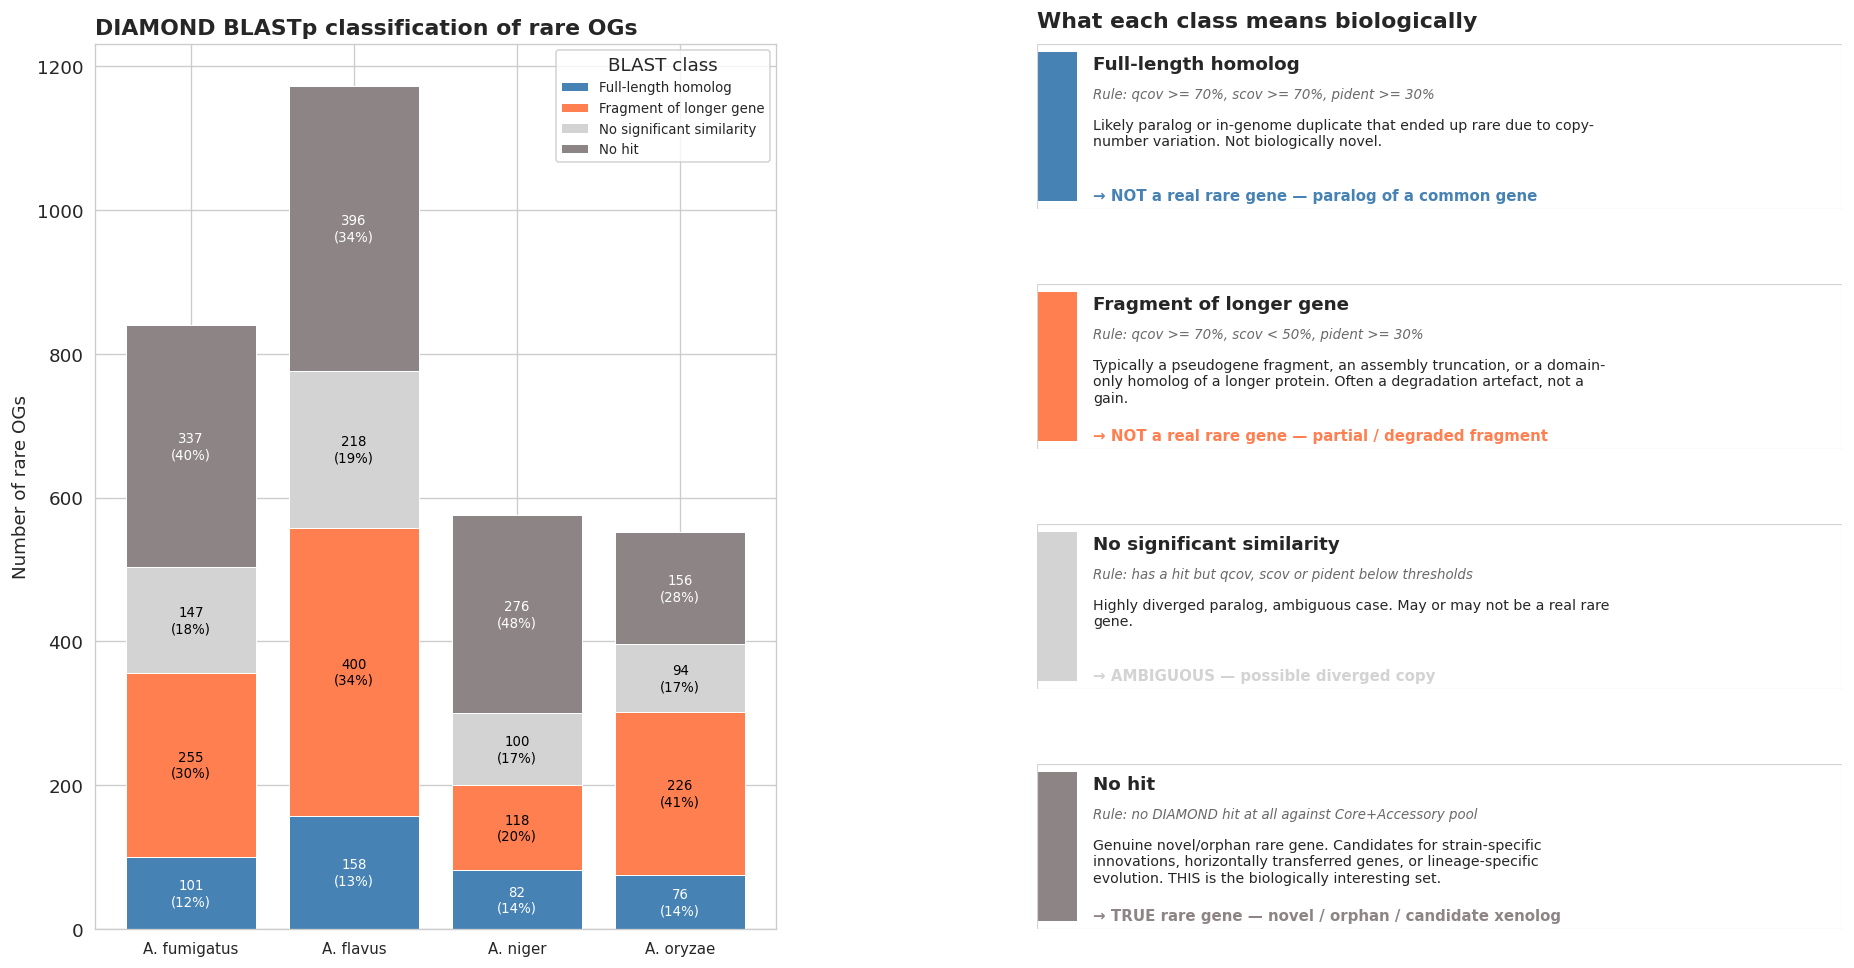

In [8]:
# --- DIAMOND breakdown with biological interpretation ---
diamond_summary = fphy.plot_diamond_classification_breakdown(
    diamond_results, SPECIES_CONFIG, RESULTS_DIR
)
display(diamond_summary)

# Print a one-line interpretation per species
print()
for _, row in diamond_summary.iterrows():
    sp = row['Species']
    n = int(row['Total'])
    if n == 0:
        continue
    print(f"{sp}: {row['No hit']}/{n} ({row['Pct_TrueRare']}%) are TRUE rare/novel; "
          f"{row['Full-length homolog']}/{n} ({row['Pct_Paralog']}%) are paralogs; "
          f"{row['Fragment of longer gene']}/{n} ({row['Pct_Fragment']}%) are fragments.")


---
## Section 4: Apply the truly-rare filter

The DIAMOND classification we just computed is loaded per species and used to
**reclassify** every Rare OG that is *not* in the `No hit` class to the new
`Rare_excluded` bin. All downstream functions filter on
`Pangenome_Class == 'Rare'`, so this single in-place reclassification routes
every subsequent analysis (deep characterization, COG enrichment, burden,
pooled mixed model, xenolog scan) onto the truly-rare subset automatically --
without changing any function signatures.

The original full rare bin sizes are still reported by Section 2; this cell
only narrows the working "Rare" definition for everything from this point
forward.


In [9]:
# --- Apply truly-rare filter: Rare OGs not in DIAMOND No-hit class -> Rare_excluded ---
truly_rare_by_sp = {}
for sp in SPECIES_LIST:
    p = os.path.join(RESULTS_DIR, sp, 'diamond_rare_classification.tsv')
    if not os.path.exists(p):
        print(f'{SPECIES_CONFIG[sp]["label"]}: missing {p} -- run Section 3 first')
        continue
    dc = pd.read_csv(p, sep='\t')
    no_hit = set(dc.loc[dc['blast_class'] == 'No hit', 'Orthogroup'])
    truly_rare_by_sp[sp] = no_hit

print('Reclassifying non-No-hit Rare OGs as "Rare_excluded"...')
print('=' * 70)
for sp in SPECIES_LIST:
    if sp not in truly_rare_by_sp:
        continue
    label = SPECIES_CONFIG[sp]['label']
    ogc = species_data[sp]['og_consensus']
    keep = truly_rare_by_sp[sp]
    rare_mask = ogc['Pangenome_Class'] == 'Rare'
    n_rare = int(rare_mask.sum())
    excl_mask = rare_mask & (~ogc['Orthogroup'].isin(keep))
    n_excl = int(excl_mask.sum())
    n_kept = n_rare - n_excl
    ogc.loc[excl_mask, 'Pangenome_Class'] = 'Rare_excluded'
    print(f'  {label:14s}: {n_rare:>5d} Rare -> {n_kept:>5d} truly-rare kept | '
          f'{n_excl:>5d} reclassified as Rare_excluded '
          f'({100*n_kept/max(n_rare,1):.1f} %% kept)')

print('\nAll downstream sections now operate on the truly-rare (No-hit) subset.')


Reclassifying non-No-hit Rare OGs as "Rare_excluded"...
  A. fumigatus  :   840 Rare ->   337 truly-rare kept |   503 reclassified as Rare_excluded (40.1 %% kept)
  A. flavus     :  1172 Rare ->   396 truly-rare kept |   776 reclassified as Rare_excluded (33.8 %% kept)
  A. niger      :   576 Rare ->   276 truly-rare kept |   300 reclassified as Rare_excluded (47.9 %% kept)
  A. oryzae     :   552 Rare ->   156 truly-rare kept |   396 reclassified as Rare_excluded (28.3 %% kept)

All downstream sections now operate on the truly-rare (No-hit) subset.


In [10]:
# --- Full per-genome burden table (all species) ---
burden_all = fphy.build_full_genome_burden_table(
    SPECIES_LIST, species_data, SPECIES_CONFIG, pheno_map, fphy.get_accession, RESULTS_DIR
)

Total genomes with phenotype labels: 211
                                mean   std  count
Species      Phenotype                           
A. flavus    Animal-pathogenic  13.0   NaN      1
             Environmental      23.8   8.3      4
             Human-pathogenic   22.5  18.3     43
             Industrial-trait   13.5   4.9      2
             Plant-pathogenic   12.4  13.0     19
             Unknown            15.0   NaN      1
A. fumigatus Environmental       5.9   9.3     49
             Human-pathogenic   18.5  12.3     37
             Unknown             7.0   1.0      3
A. niger     Environmental      32.2  12.7      6
             Human-pathogenic   39.0   NaN      1
             Industrial-trait   25.3  17.8     12
A. oryzae    Environmental      38.0   NaN      1
             Industrial-trait   10.2   6.5     32

Saved: /datadrive/Analysis/NB4_Results/rare_gene_burden_all_genomes.csv


Saved main characterisation figure


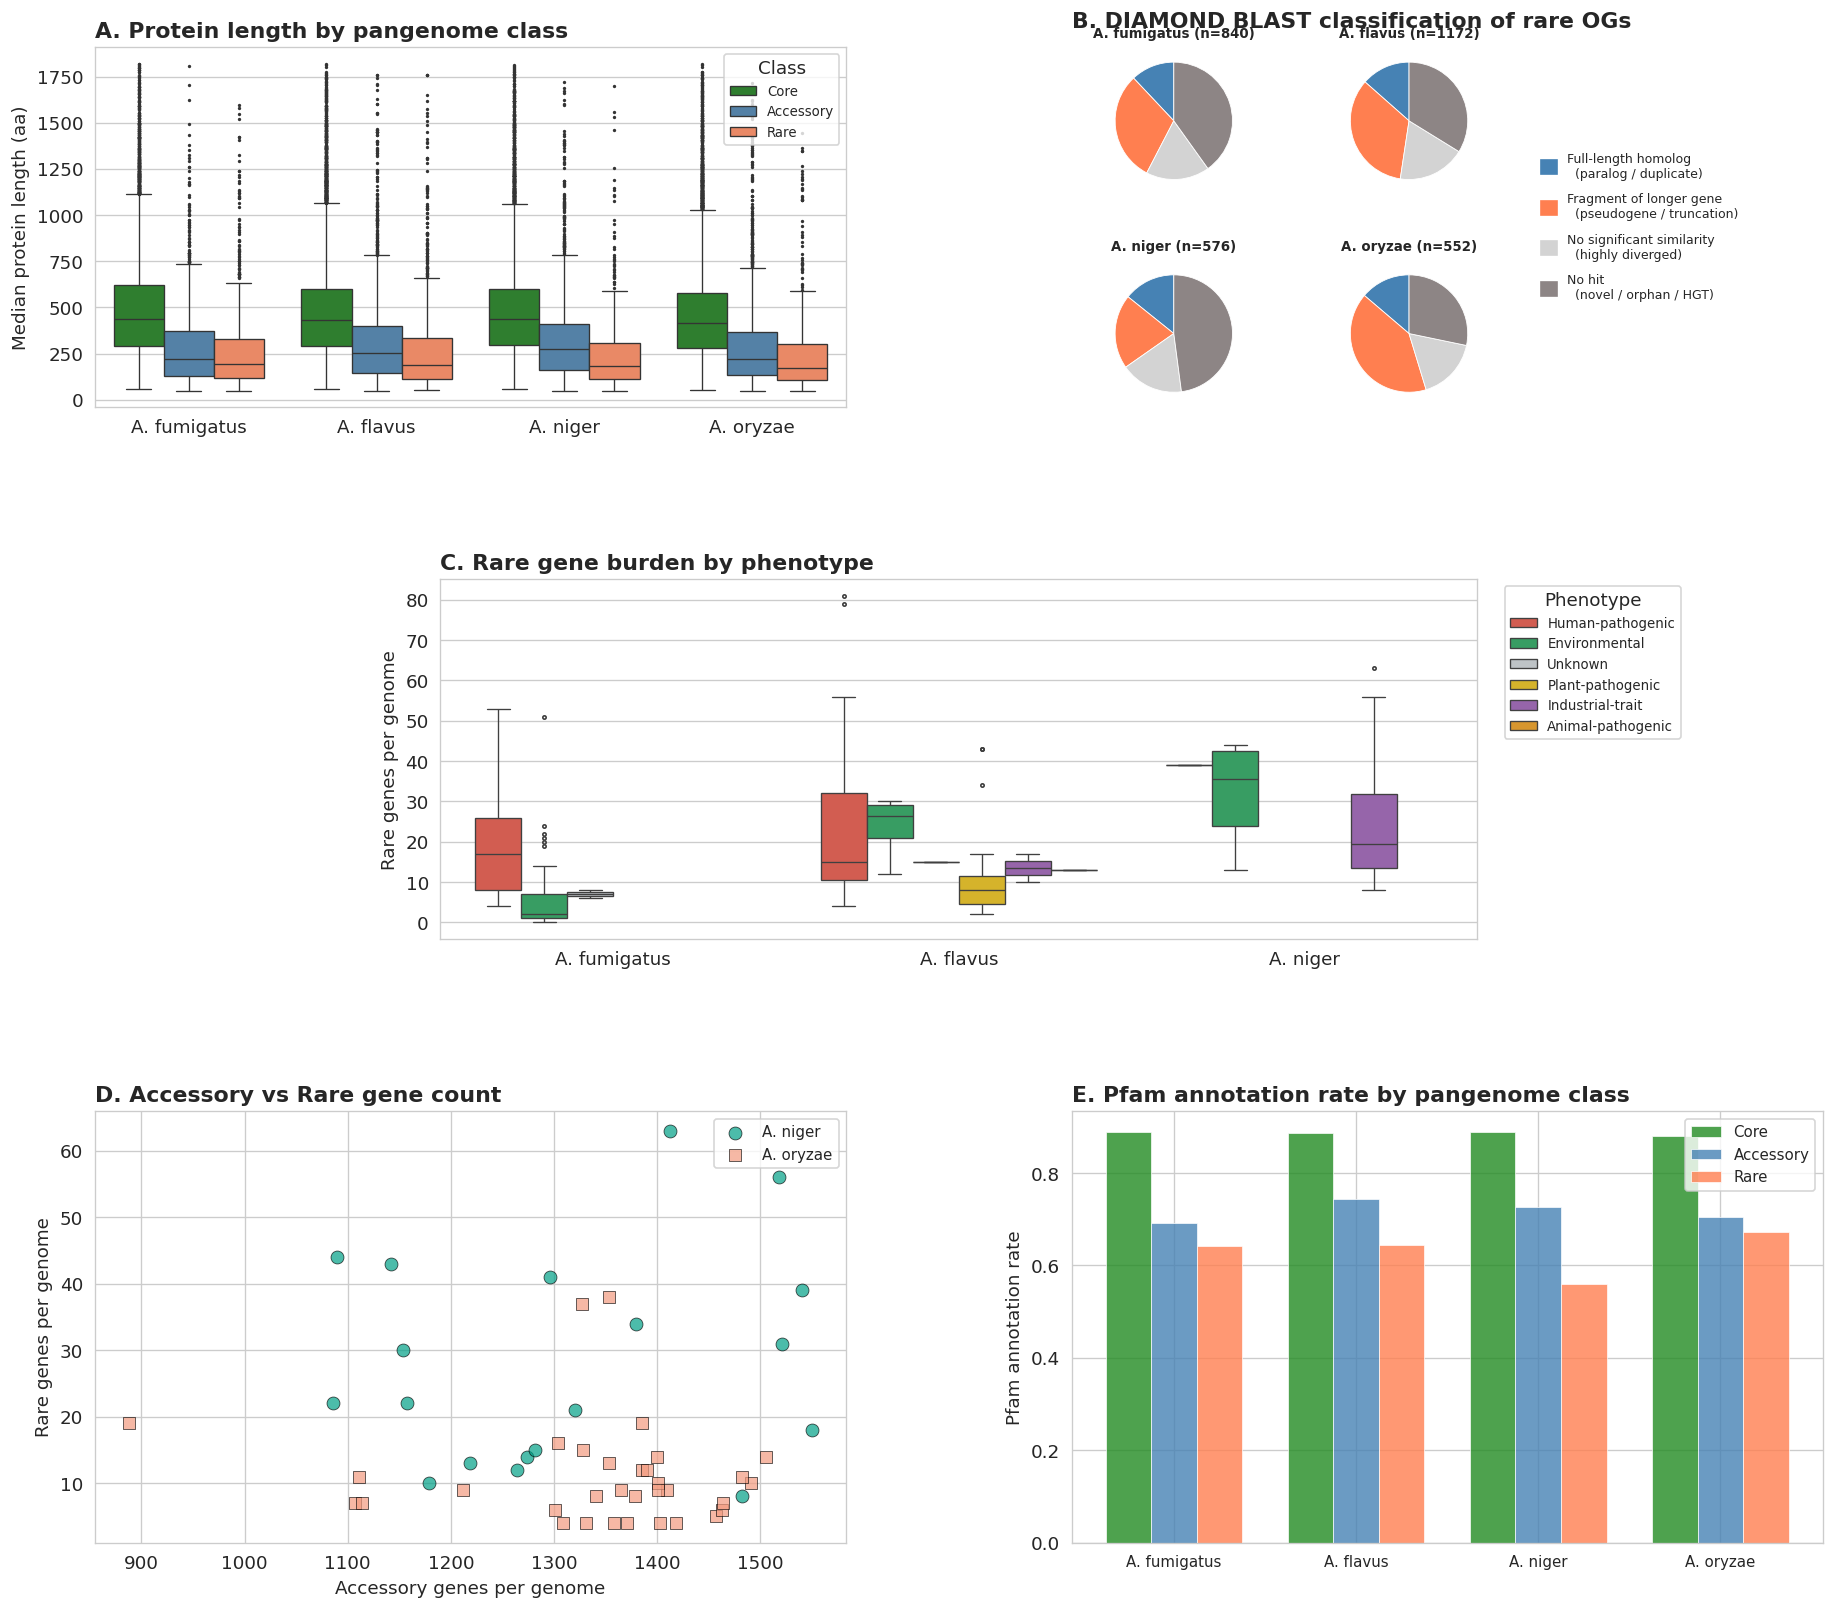

In [11]:
# --- Composite characterisation figure ---
fphy.plot_rare_characterisation_figure(
    SPECIES_DEEP, length_data, diamond_results,
    burden_all, rates_df, SPECIES_CONFIG, RESULTS_DIR
)

In [12]:
# Save characterisation summary
class_order = ['Core', 'Accessory', 'Rare']
char_rows = []
for sp in SPECIES_DEEP:
    df_len = length_data.get(sp, pd.DataFrame())
    df_dia = diamond_results.get(sp, pd.DataFrame())

    for cls in class_order:
        sub = df_len[df_len['Pangenome_Class'] == cls] if not df_len.empty else pd.DataFrame()
        char_rows.append({
            'Species': f'A. {sp}',
            'Class': cls,
            'n_OGs': len(sub),
            'median_protein_len': sub['median_len'].median() if not sub.empty else np.nan,
        })

char_df = pd.DataFrame(char_rows)
char_df.to_csv(f'{RESULTS_DIR}/rare_gene_characterisation_summary.csv', index=False)
print(f'Saved: {RESULTS_DIR}/rare_gene_characterisation_summary.csv')
display(char_df)


Saved: /datadrive/Analysis/NB4_Results/rare_gene_characterisation_summary.csv


,Species,Class,n_OGs,median_protein_len
0,A. fumigatus,Core,8382,442.00
1,A. fumigatus,Accessory,1729,223.00
2,A. fumigatus,Rare,840,193.00
3,A. flavus,Core,10675,437.00
4,A. flavus,Accessory,2616,255.00
5,A. flavus,Rare,1172,188.00
6,A. niger,Core,9422,440.00
7,A. niger,Accessory,2455,277.00
8,A. niger,Rare,576,186.75
9,A. oryzae,Core,11090,419.00


---
## Section 5: Deep Characterization of the truly-rare compartment



Saved: /datadrive/Analysis/NB4_Results/rare_ogs_characterization.png


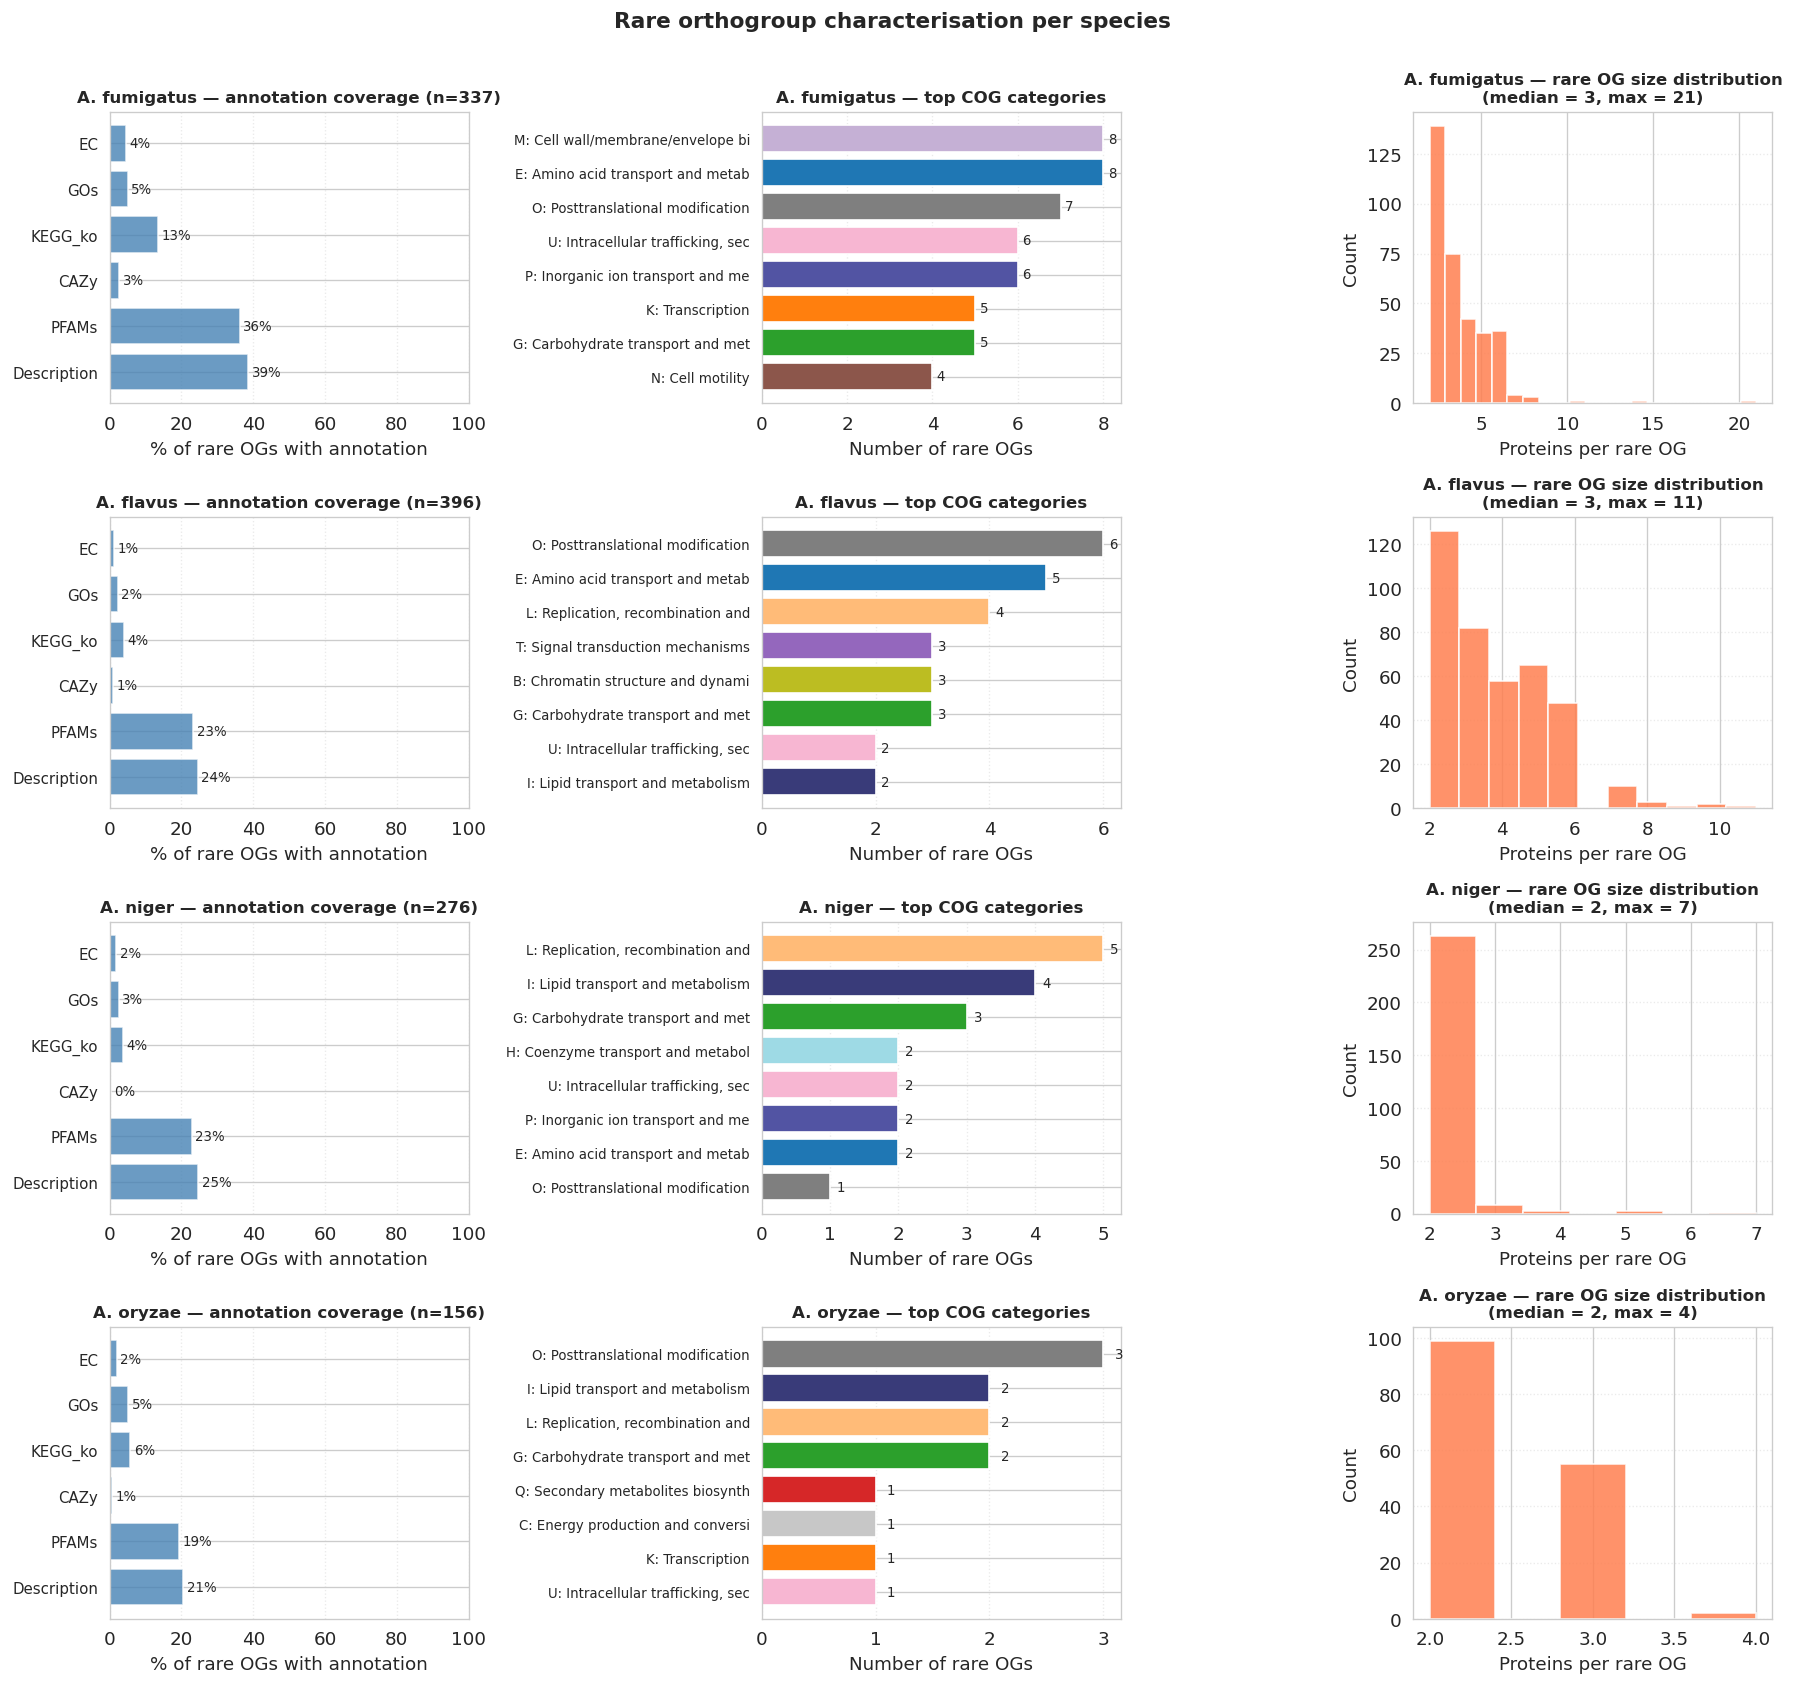

In [13]:
# --- Visualise rare-OG characterisation across all species ---
fphy.plot_rare_ogs_characterization(
    SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR
)


---
## Section 6: Functional Enrichment (truly-rare vs Non-Rare)

Fisher's exact test for COG category enrichment in the rare compartment,
and annotation rate comparison across Core/Accessory/Rare.

In [14]:
# --- COG enrichment: Rare vs Non-Rare ---
cog_enrich_df = fphy.run_rare_cog_enrichment(SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR)
sig = cog_enrich_df[cog_enrich_df['Significant']] if len(cog_enrich_df) > 0 else pd.DataFrame()
if len(sig) > 0:
    display(sig[['Species', 'COG', 'COG_description', 'Rare_count', 'NonRare_count',
                 'Odds_Ratio', 'q_value']].head(20))

Saved: /datadrive/Analysis/NB4_Results/cog_enrichment_rare_vs_nonrare.csv

Significant enrichments (FDR < 0.05): 2


,Species,COG,COG_description,Rare_count,NonRare_count,Odds_Ratio,q_value
13,A. fumigatus,N,Cell motility,4,5,65.284404,0.000259
12,A. fumigatus,M,Cell wall/membrane/envelope biogenesis,8,103,6.507258,0.003308


---
## Section 7: Truly-rare Gene Burden by Phenotype

For each species, count rare genes per genome, overlay phenotype,
and test whether pathogenic or industrial strains carry different rare gene loads.

In [15]:
# --- Per-species rare gene burden test ---
burden_df = fphy.compute_rare_burden_by_phenotype(
    SPECIES_LIST, species_data, SPECIES_CONFIG, pheno_map, fphy.get_accession, RESULTS_DIR
)
if len(burden_df) > 0:
    display(burden_df)


A. fumigatus: rare gene burden, one-vs-rest
  Environmental (n=49, mean=5.9) vs rest (n=37, mean=18.5)  U=246, P=8.12e-09  [Environmental lower]
  Human-pathogenic (n=37, mean=18.5) vs rest (n=49, mean=5.9)  U=1566, P=8.12e-09  [Human-pathogenic higher]

A. flavus: rare gene burden, one-vs-rest
  [skip] Animal-pathogenic: n_case=1, n_ctrl=68
  Environmental (n=4, mean=23.8) vs rest (n=65, mean=19.1)  U=176, P=2.37e-01  [Environmental higher]
  Human-pathogenic (n=43, mean=22.5) vs rest (n=26, mean=14.2)  U=757, P=1.44e-02  [Human-pathogenic higher]
  [skip] Industrial-trait: n_case=2, n_ctrl=67
  Plant-pathogenic (n=19, mean=12.4) vs rest (n=50, mean=22.0)  U=235, P=1.28e-03  [Plant-pathogenic lower]

A. niger: rare gene burden, one-vs-rest
  Environmental (n=6, mean=32.2) vs rest (n=13, mean=26.4)  U=52, P=2.92e-01  [Environmental higher]
  [skip] Human-pathogenic: n_case=1, n_ctrl=18
  Industrial-trait (n=12, mean=25.3) vs rest (n=7, mean=33.1)  U=26, P=1.76e-01  [Industrial-trait l

,Species,Group1,Group2,n_g1,n_g2,mean_g1,mean_g2,U_stat,p_value,direction
0,A. fumigatus,Environmental,Rest,49,37,5.938776,18.486486,246.5,8.116824e-09,lower
1,A. fumigatus,Human-pathogenic,Rest,37,49,18.486486,5.938776,1566.5,8.116824e-09,higher
2,A. flavus,Environmental,Rest,4,65,23.750000,19.107692,176.5,2.371317e-01,higher
3,A. flavus,Human-pathogenic,Rest,43,26,22.488372,14.230769,757.0,1.437650e-02,higher
4,A. flavus,Plant-pathogenic,Rest,19,50,12.368421,22.040000,235.0,1.281818e-03,lower
5,A. niger,Environmental,Rest,6,13,32.166667,26.384615,51.5,2.923724e-01,higher
6,A. niger,Industrial-trait,Rest,12,7,25.333333,33.142857,25.5,1.761067e-01,lower


In [16]:
# --- Interpretation: Rare Gene Burden by Phenotype ---
print('Rare Gene Burden by Phenotype')
print('=' * 60)
if 'burden_df' in dir() and len(burden_df) > 0:
    for _, row in burden_df.iterrows():
        sp = row['Species']
        g1, g2 = row['Group1'], row['Group2']
        m1, m2 = row['mean_g1'], row['mean_g2']
        n1, n2 = row['n_g1'], row['n_g2']
        pval = row['p_value']
        direction = row['direction']
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        print(f'  {sp}: {g1} (n={n1}, mean={m1:.1f}) vs {g2} (n={n2}, mean={m2:.1f})')
        print(f'       Mann-Whitney p={pval:.2e} {sig} -- {g1} burden is {direction}')
else:
    print('  (Run burden analysis cell above first)')


Rare Gene Burden by Phenotype
  A. fumigatus: Environmental (n=49, mean=5.9) vs Rest (n=37, mean=18.5)
       Mann-Whitney p=8.12e-09 *** -- Environmental burden is lower
  A. fumigatus: Human-pathogenic (n=37, mean=18.5) vs Rest (n=49, mean=5.9)
       Mann-Whitney p=8.12e-09 *** -- Human-pathogenic burden is higher
  A. flavus: Environmental (n=4, mean=23.8) vs Rest (n=65, mean=19.1)
       Mann-Whitney p=2.37e-01 ns -- Environmental burden is higher
  A. flavus: Human-pathogenic (n=43, mean=22.5) vs Rest (n=26, mean=14.2)
       Mann-Whitney p=1.44e-02 * -- Human-pathogenic burden is higher
  A. flavus: Plant-pathogenic (n=19, mean=12.4) vs Rest (n=50, mean=22.0)
       Mann-Whitney p=1.28e-03 ** -- Plant-pathogenic burden is lower
  A. niger: Environmental (n=6, mean=32.2) vs Rest (n=13, mean=26.4)
       Mann-Whitney p=2.92e-01 ns -- Environmental burden is higher
  A. niger: Industrial-trait (n=12, mean=25.3) vs Rest (n=7, mean=33.1)
       Mann-Whitney p=1.76e-01 ns -- Industria

---
## Section 7b: Pooled cross-species truly-rare-burden mixed-effects model

The within-species Mann-Whitney tests in Section 5 are individually underpowered for 
the industrial-trait contrast (n_industrial = 2 to 32 per species; A. niger industrial-vs-rest 
p = 0.237; A. oryzae untestable due to 32:1 imbalance). To obtain a single cross-species 
statistic we fit a linear mixed-effects model `Rare_genes ~ phenotype + (1|species)` to:

1. **Industrial-trait vs Environmental** across all four species (46 industrial + 60 environmental = 106 genomes).
2. **Human-pathogenic vs Environmental** across A. fumigatus, A. flavus, and A. niger (81 + 60 = 141 genomes; A. oryzae has zero human-pathogenic isolates).

Species is a random intercept that absorbs species-level genome-size differences. 
We report both the raw-count fit (interpretable as fewer/more rare genes per genome) 
and a `log(rare + 1)` sensitivity fit (interpretable as fold change). 
Outputs: `pooled_burden_mixed_model.csv`, `pooled_burden_forest.png`.


In [17]:
# --- 5b: Pooled cross-species rare-burden mixed-effects model ---
import statsmodels.formula.api as smf

burden_all = pd.read_csv(os.path.join(RESULTS_DIR, 'rare_gene_burden_all_genomes.csv'))

def fit_pooled_mixed(df, fixed_col, contrast_label):
    """Fit Rare_genes ~ fixed_col + (1|Species); also log-transform sensitivity."""
    m = smf.mixedlm(f'Rare_genes ~ {fixed_col}', df, groups=df['Species']).fit(reml=False)
    log_df = df.copy()
    log_df['log_rare'] = np.log(log_df['Rare_genes'] + 1)
    m_log = smf.mixedlm(f'log_rare ~ {fixed_col}', log_df, groups=log_df['Species']).fit(reml=False)
    sp_ct = pd.crosstab(df['Species'], df[fixed_col])
    return {
        'contrast': contrast_label,
        'n_total': int(m.nobs),
        'n_case': int((df[fixed_col] == 1).sum()),
        'n_ctrl': int((df[fixed_col] == 0).sum()),
        'species_with_both_groups': int((sp_ct.min(axis=1) > 0).sum()),
        'beta_raw': float(m.params[fixed_col]),
        'se_raw':   float(m.bse[fixed_col]),
        'p_raw':    float(m.pvalues[fixed_col]),
        'CI_low_raw':  float(m.conf_int().loc[fixed_col, 0]),
        'CI_high_raw': float(m.conf_int().loc[fixed_col, 1]),
        'beta_log':         float(m_log.params[fixed_col]),
        'fold_change_log':  float(np.exp(m_log.params[fixed_col])),
        'p_log':            float(m_log.pvalues[fixed_col]),
        'species_var':  float(m.cov_re.iloc[0, 0]),
        'residual_var': float(m.scale),
    }

# Test 1: Industrial-trait vs Environmental (all four species)
ind_env = burden_all[burden_all['Phenotype'].isin(['Industrial-trait', 'Environmental'])].copy()
ind_env['phenotype_industrial'] = (ind_env['Phenotype'] == 'Industrial-trait').astype(int)
res1 = fit_pooled_mixed(ind_env, 'phenotype_industrial', 'Industrial vs Environmental')

# Test 2: Human-pathogenic vs Environmental (3 species; oryzae has 0 HP)
hp_env = burden_all[burden_all['Phenotype'].isin(['Human-pathogenic', 'Environmental'])].copy()
hp_env['phenotype_pathogenic'] = (hp_env['Phenotype'] == 'Human-pathogenic').astype(int)
res2 = fit_pooled_mixed(hp_env, 'phenotype_pathogenic', 'Human-pathogenic vs Environmental')

pooled_df = pd.DataFrame([res1, res2])
pooled_df.to_csv(os.path.join(RESULTS_DIR, 'pooled_burden_mixed_model.csv'), index=False)

print('Pooled cross-species rare-burden mixed-effects model')
print('=' * 70)
for r in [res1, res2]:
    print(f"\n{r['contrast']}")
    print(f"  n = {r['n_total']} ({r['n_case']} cases, {r['n_ctrl']} controls); "
          f"{r['species_with_both_groups']}/4 species contribute both groups")
    print(f"  Raw counts:    beta = {r['beta_raw']:+.2f} rare genes "
          f"[{r['CI_low_raw']:+.2f}, {r['CI_high_raw']:+.2f}], p = {r['p_raw']:.2e}")
    print(f"  Log-transform: fold change = {r['fold_change_log']:.2f}x, p = {r['p_log']:.2e}")
    print(f"  Species random-effect variance = {r['species_var']:.1f}")

display(pooled_df)


Pooled cross-species rare-burden mixed-effects model

Industrial vs Environmental
  n = 106 (46 cases, 60 controls); 3/4 species contribute both groups
  Raw counts:    beta = -9.37 rare genes [-17.16, -1.58], p = 1.83e-02
  Log-transform: fold change = 0.66x, p = 2.00e-01
  Species random-effect variance = 98.6

Human-pathogenic vs Environmental
  n = 141 (81 cases, 60 controls); 3/4 species contribute both groups
  Raw counts:    beta = +9.78 rare genes [+4.53, +15.04], p = 2.61e-04
  Log-transform: fold change = 3.06x, p = 2.85e-11
  Species random-effect variance = 99.8


,contrast,n_total,n_case,n_ctrl,species_with_both_groups,beta_raw,se_raw,p_raw,CI_low_raw,CI_high_raw,beta_log,fold_change_log,p_log,species_var,residual_var
0,Industrial vs Environmental,106,46,60,3,-9.370329,3.972614,0.018338,-17.156510,-1.584148,-0.412266,0.662148,2.002695e-01,98.620306,101.115337
1,Human-pathogenic vs Environmental,141,81,60,3,9.784713,2.679664,0.000261,4.532668,15.036757,1.117487,3.057163,2.854098e-11,99.768740,184.724634


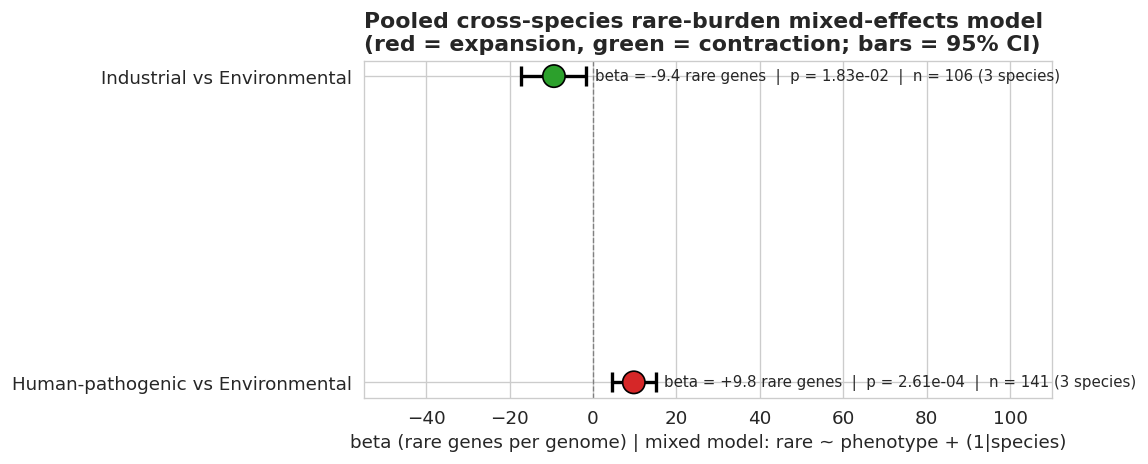

In [18]:
# --- 5b figure: forest plot of pooled mixed-effects results ---
fig, ax = plt.subplots(figsize=(9, 4))
y_positions = np.arange(len(pooled_df))
colors = ['#2ca02c' if b < 0 else '#d62728' for b in pooled_df['beta_raw']]
ax.errorbar(pooled_df['beta_raw'], y_positions,
            xerr=[pooled_df['beta_raw'] - pooled_df['CI_low_raw'],
                  pooled_df['CI_high_raw'] - pooled_df['beta_raw']],
            fmt='none', capsize=6, capthick=2, linewidth=2,
            ecolor='black')
ax.scatter(pooled_df['beta_raw'], y_positions, s=180, c=colors,
           edgecolor='black', linewidth=1, zorder=3)
for i, (_, r) in enumerate(pooled_df.iterrows()):
    ax.text(r['CI_high_raw'] + 2, i,
            f"beta = {r['beta_raw']:+.1f} rare genes  |  "
            f"p = {r['p_raw']:.2e}  |  n = {r['n_total']} "
            f"({r['species_with_both_groups']} species)",
            va='center', fontsize=9)
ax.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_yticks(y_positions)
ax.set_yticklabels(pooled_df['contrast'])
ax.set_xlabel('beta (rare genes per genome) | mixed model: rare ~ phenotype + (1|species)')
ax.set_title('Pooled cross-species rare-burden mixed-effects model\n'
             '(red = expansion, green = contraction; bars = 95% CI)',
             loc='left', fontweight='bold')
xmax_data = max(pooled_df['CI_high_raw'].max(), 50)
ax.set_xlim(min(pooled_df['CI_low_raw'].min() - 5, -55), xmax_data * 2.2)
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'pooled_burden_forest.png'),
            dpi=200, bbox_inches='tight')
plt.show()


---
## Section 8: Xenolog Detection (within the truly-rare subset)

Identify HGT candidates via GC content deviation, then query NCBI BLAST
to determine taxonomic origin.

In [19]:
# --- Xenolog detection: NCBI BLASTp on GC-outlier rare OGs ---
# Pre-filter rare OGs to those whose representative protein has
# |GC content| > 2 SD from the species mean. This is the standard
# proxy for HGT/xenolog candidates (vs BLASTing arbitrary first-N).
# Resumable: cached to NB4_Results/rare_xenolog_ncbi_blast_results.tsv
FORCE_BLAST   = False    # True = re-BLAST every OG, ignore cache
USE_GC_FILTER = True     # True = GC outliers only; False = first N_PER_SPECIES
GC_THRESHOLD  = 3.0      # SD cutoff for the GC filter
N_PER_SPECIES = 20       # only used if USE_GC_FILTER=False

# Quick dry-run: how many candidates per species before BLASTing?
if USE_GC_FILTER:
    print('Dry-run candidate counts:')
    _ = fphy.find_gc_outlier_rare_ogs(SPECIES_LIST, species_data, BASE_PATH,
                                      gc_threshold=GC_THRESHOLD)
    print()

blast_df = fphy.run_ncbi_blast_xenologs(
    SPECIES_LIST, species_data, SPECIES_CONFIG,
    BASE_PATH, RESULTS_DIR,
    n_per_species=N_PER_SPECIES, force=FORCE_BLAST,
    gc_filter=USE_GC_FILTER, gc_threshold=GC_THRESHOLD,
)

if len(blast_df) > 0:
    org_cols = [c for c in ['organism', 'top_hit_organism', 'subject_organism']
                if c in blast_df.columns]
    if org_cols:
        print(f'\nTaxonomic origin distribution (top BLAST hits):')
        print(blast_df[org_cols[0]].value_counts().head(10).to_string())
    display(blast_df.head(20))


Dry-run candidate counts:
  fumigatus: 17 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=337)
  flavus: 15 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=396)
  niger: 13 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=276)
  oryzae: 8 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=156)

Backed up existing cache -> /datadrive/Analysis/NB4_Results/rare_xenolog_ncbi_blast_results.tsv.bak
Resuming: 72 (species, OG) pairs already in /datadrive/Analysis/NB4_Results/rare_xenolog_ncbi_blast_results.tsv
GC-deviation filter active (|GC_dev| > 3.0 SD); BLASTing all candidates (n_per_species ignored)
  fumigatus: 17 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=337)
  flavus: 15 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=396)
  niger: 13 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=276)
  oryzae: 8 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=156)
  fumigatus: queued 0 new rare OGs (skipping 17 cached)
  flavus: queued 0 new rare OGs (skipping 15 cached)
  niger: queued 0 new rare

,species,orthogroup,accession,description,organism,pident,evalue
0,fumigatus,OG0010203,CAO5976858,Hypothetical protein CAMPOLS_039341 [Perkinsus...,Perkinsus olseni,33.532934,7.987880e-02
1,fumigatus,OG0010203,KAF3828726,hypothetical protein GH733_004632 [Mirounga le...,Mirounga leonina,26.011561,2.649090e+00
2,fumigatus,OG0010203,ETM02348,"hypothetical protein L917_01171, partial [Phyt...",Phytophthora nicotianae,36.507937,4.555910e+00
3,fumigatus,OG0010213,KAH1796053,hypothetical protein KXX36_002078 [Aspergillus...,Aspergillus fumigatus,93.243243,1.264200e-90
4,fumigatus,OG0010213,EDP48471,"hypothetical protein AFUB_091880, partial [Asp...",Aspergillus fumigatus A1163,100.000000,3.539420e-75
5,fumigatus,OG0010213,XP_748877,uncharacterized protein AFUA_7G06330 [Aspergil...,Aspergillus fumigatus Af293,98.260870,7.707080e-75
6,fumigatus,OG0010213,RECOVERED,(top-1 hit reconstructed from prior session ou...,Aspergillus fumigatus,93.243243,1.264200e-90
7,fumigatus,OG0010279,RECOVERED,(top-1 hit reconstructed from prior session ou...,Bacteroidota bacterium,38.571429,2.215110e+00
8,fumigatus,OG0010332,RECOVERED,(top-1 hit reconstructed from prior session ou...,Aspergillus fumigatus,87.234043,5.384970e-15
9,fumigatus,OG0010503,RECOVERED,(top-1 hit reconstructed from prior session ou...,Aspergillus fumigatus,100.000000,8.745640e-57


Restricting BLAST table to truly-rare OGs: 92 -> 65 rows (27 hits dropped from now-Rare_excluded OGs)
Saved: /datadrive/Analysis/NB4_Results/rare_xenolog_taxonomy.png

Saved: /datadrive/Analysis/NB4_Results/rare_xenolog_kingdom_summary.csv



kingdom_filtered,Aspergillus (self),Other fungi,Bacteria,Protist,Plant,Animal,Virus,Unknown,Weak / no hit,Total,Confident xenologs
species,,,,,,,,,,,
flavus,10,0,1,0,0,0,0,0,1,12,1
fumigatus,9,0,1,0,0,1,0,0,2,13,2
niger,11,0,0,0,0,0,0,0,0,11,0
oryzae,6,0,0,0,0,0,0,0,1,7,0


Confident non-fungal top hits: 3
Saved: /datadrive/Analysis/NB4_Results/rare_xenolog_confident_hits.csv


,species,orthogroup,organism,kingdom,pident,evalue
42,flavus,OG0014462,Stenotrophomonas maltophilia,Bacteria,98.369565,0.000000e+00
12,fumigatus,OG0010936,Stenotrophomonas maltophilia,Bacteria,64.968153,4.141290e-49
6,fumigatus,OG0010578,Rhipicephalus sanguineus,Animal,96.470588,1.135070e-23


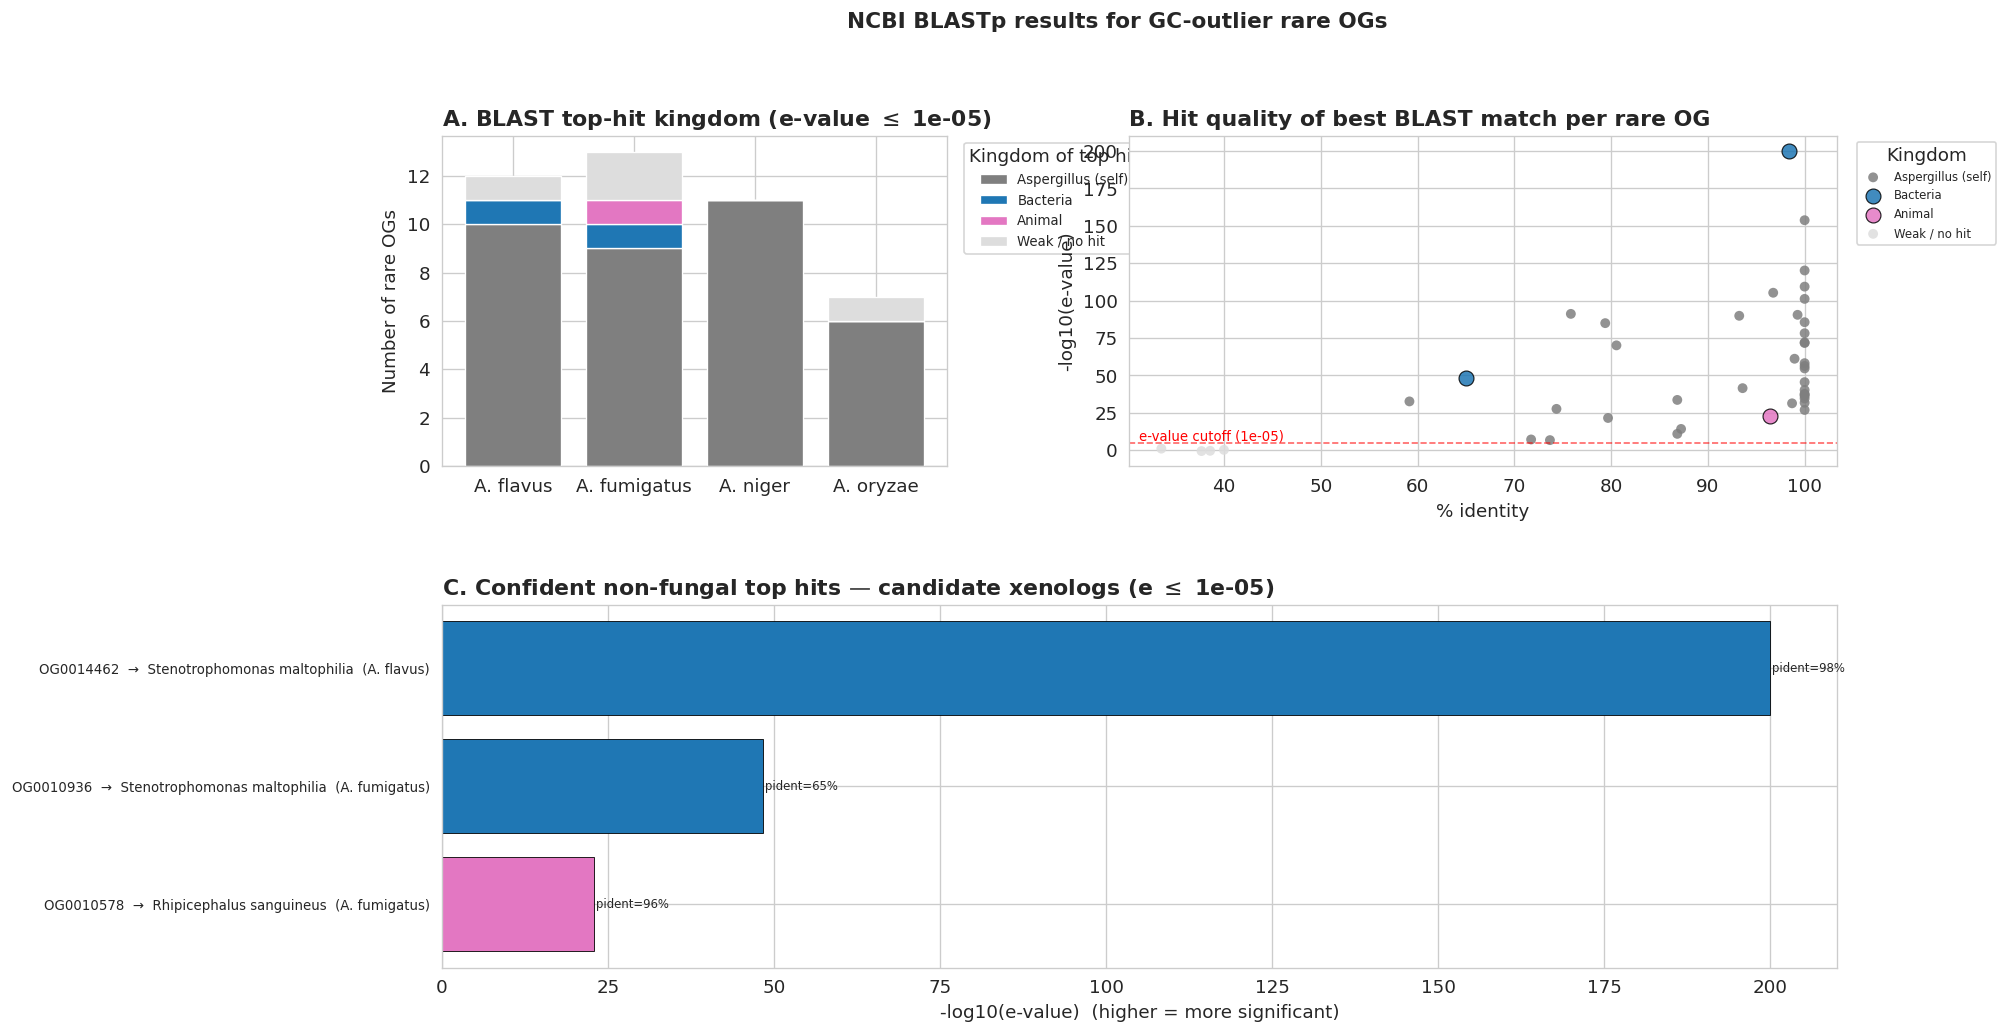

In [20]:
# --- Section 8 visualisation: BLAST taxonomy of truly-rare GC-outlier OGs ---
# Confident xenologs = non-fungal top hits with e-value <= 1e-5.
# This filters out random matches (raw e>1) and Aspergillus self-paralogs.
# Cache may contain BLAST hits for OGs that are now classified as Rare_excluded
# (paralogs/fragments under the DIAMOND filter); restrict to truly-rare here so
# the displayed taxonomy and confident-hit count reflect the cleaned substrate.
EVALUE_CUTOFF = 1e-5

if 'truly_rare_by_sp' in dir() and len(truly_rare_by_sp):
    n_before = len(blast_df)
    keep_pairs = {(sp, og) for sp, ogs in truly_rare_by_sp.items() for og in ogs}
    blast_df = blast_df[blast_df.apply(
        lambda r: (str(r['species']), str(r['orthogroup'])) in keep_pairs,
        axis=1)].copy()
    print(f'Restricting BLAST table to truly-rare OGs: '
          f'{n_before} -> {len(blast_df)} rows '
          f'({n_before - len(blast_df)} hits dropped from now-Rare_excluded OGs)')

xeno_top = fphy.plot_xenolog_taxonomy(
    blast_df, SPECIES_CONFIG, RESULTS_DIR, evalue_cutoff=EVALUE_CUTOFF
)

# --- Summary table per species ---
summary = (xeno_top.groupby(['species', 'kingdom_filtered']).size()
                  .unstack(fill_value=0)
                  .reindex(columns=['Aspergillus (self)', 'Other fungi',
                                    'Bacteria', 'Protist', 'Plant', 'Animal',
                                    'Virus', 'Unknown', 'Weak / no hit'],
                           fill_value=0))
summary['Total'] = summary.sum(axis=1)
summary['Confident xenologs'] = summary[['Bacteria', 'Protist', 'Plant',
                                          'Animal', 'Virus']].sum(axis=1)
summary.to_csv(f'{RESULTS_DIR}/rare_xenolog_kingdom_summary.csv')
print(f'\nSaved: {RESULTS_DIR}/rare_xenolog_kingdom_summary.csv\n')
display(summary)

# --- Confident xenolog table (the actual HGT candidates) ---
confident = xeno_top[
    ~xeno_top['kingdom_filtered'].isin(['Aspergillus (self)', 'Other fungi',
                                         'Weak / no hit', 'Unknown'])
].sort_values('evalue').copy()
confident.to_csv(f'{RESULTS_DIR}/rare_xenolog_confident_hits.csv', index=False)
print(f'Confident non-fungal top hits: {len(confident)}')
print(f'Saved: {RESULTS_DIR}/rare_xenolog_confident_hits.csv')
if len(confident) > 0:
    display(confident[['species', 'orthogroup', 'organism', 'kingdom',
                        'pident', 'evalue']])


---
## Section 9: Phylogenetic Signal & Ancestral Reconstruction

For each species:
1. Load IQ-TREE tree from Gubbins recombination-filtered SNP alignments
2. Fritz & Purvis D statistic for phylogenetic signal of phenotype
3. Ancestral niche reconstruction (Fitch parsimony)
4. Gene gain/loss events


A. fumigatus -- Phylogenetic Analysis
  Loading tree from: /datadrive/Species/Aspergillus/fumigatus/iqtree_output_snv/gubbins_tree.contree
  Tree: 89 tips

  --- Fritz & Purvis D (phylogenetic signal) ---
  Phenotypes in tree: {'Human-pathogenic', 'Environmental'}
    Environmental: D=0.054, p(random)=0.000 *
    Human-pathogenic: D=0.067, p(random)=0.000 *
  Saved: /datadrive/Analysis/NB4_Results/fumigatus/phylogenetic_signal.png

  --- Gene gain/loss events ---


  Gain/loss events: 2066 OGs analysed
  Mean parsimony changes: 10.61
  Saved: /datadrive/Analysis/NB4_Results/fumigatus/gain_loss_events.tsv
  Saved: /datadrive/Analysis/NB4_Results/fumigatus/gain_loss_summary.tsv

  --- Ancestral niche reconstruction ---
  Saved: /datadrive/Analysis/NB4_Results/fumigatus/ancestral_niche_reconstruction.png

A. flavus -- Phylogenetic Analysis
  Loading tree from: /datadrive/Species/Aspergillus/flavus/iqtree_output_snv/gubbins_tree.contree
  Pruned ANI-excluded: GCA_023653635.1
  Tree: 70 tips

  --- Fritz & Purvis D (phylogenetic signal) ---
  Phenotypes in tree: {'Human-pathogenic', 'Environmental', 'Plant-pathogenic', 'Industrial-trait', 'Animal-pathogenic'}
    Animal-pathogenic: n=1, too few for D test
    Environmental: D=0.541, p(random)=0.054 ns
    Human-pathogenic: D=0.279, p(random)=0.000 *
    Industrial-trait: n=2, too few for D test
    Plant-pathogenic: D=-0.094, p(random)=0.000 *
  Saved: /datadrive/Analysis/NB4_Results/flavus/phylogenet

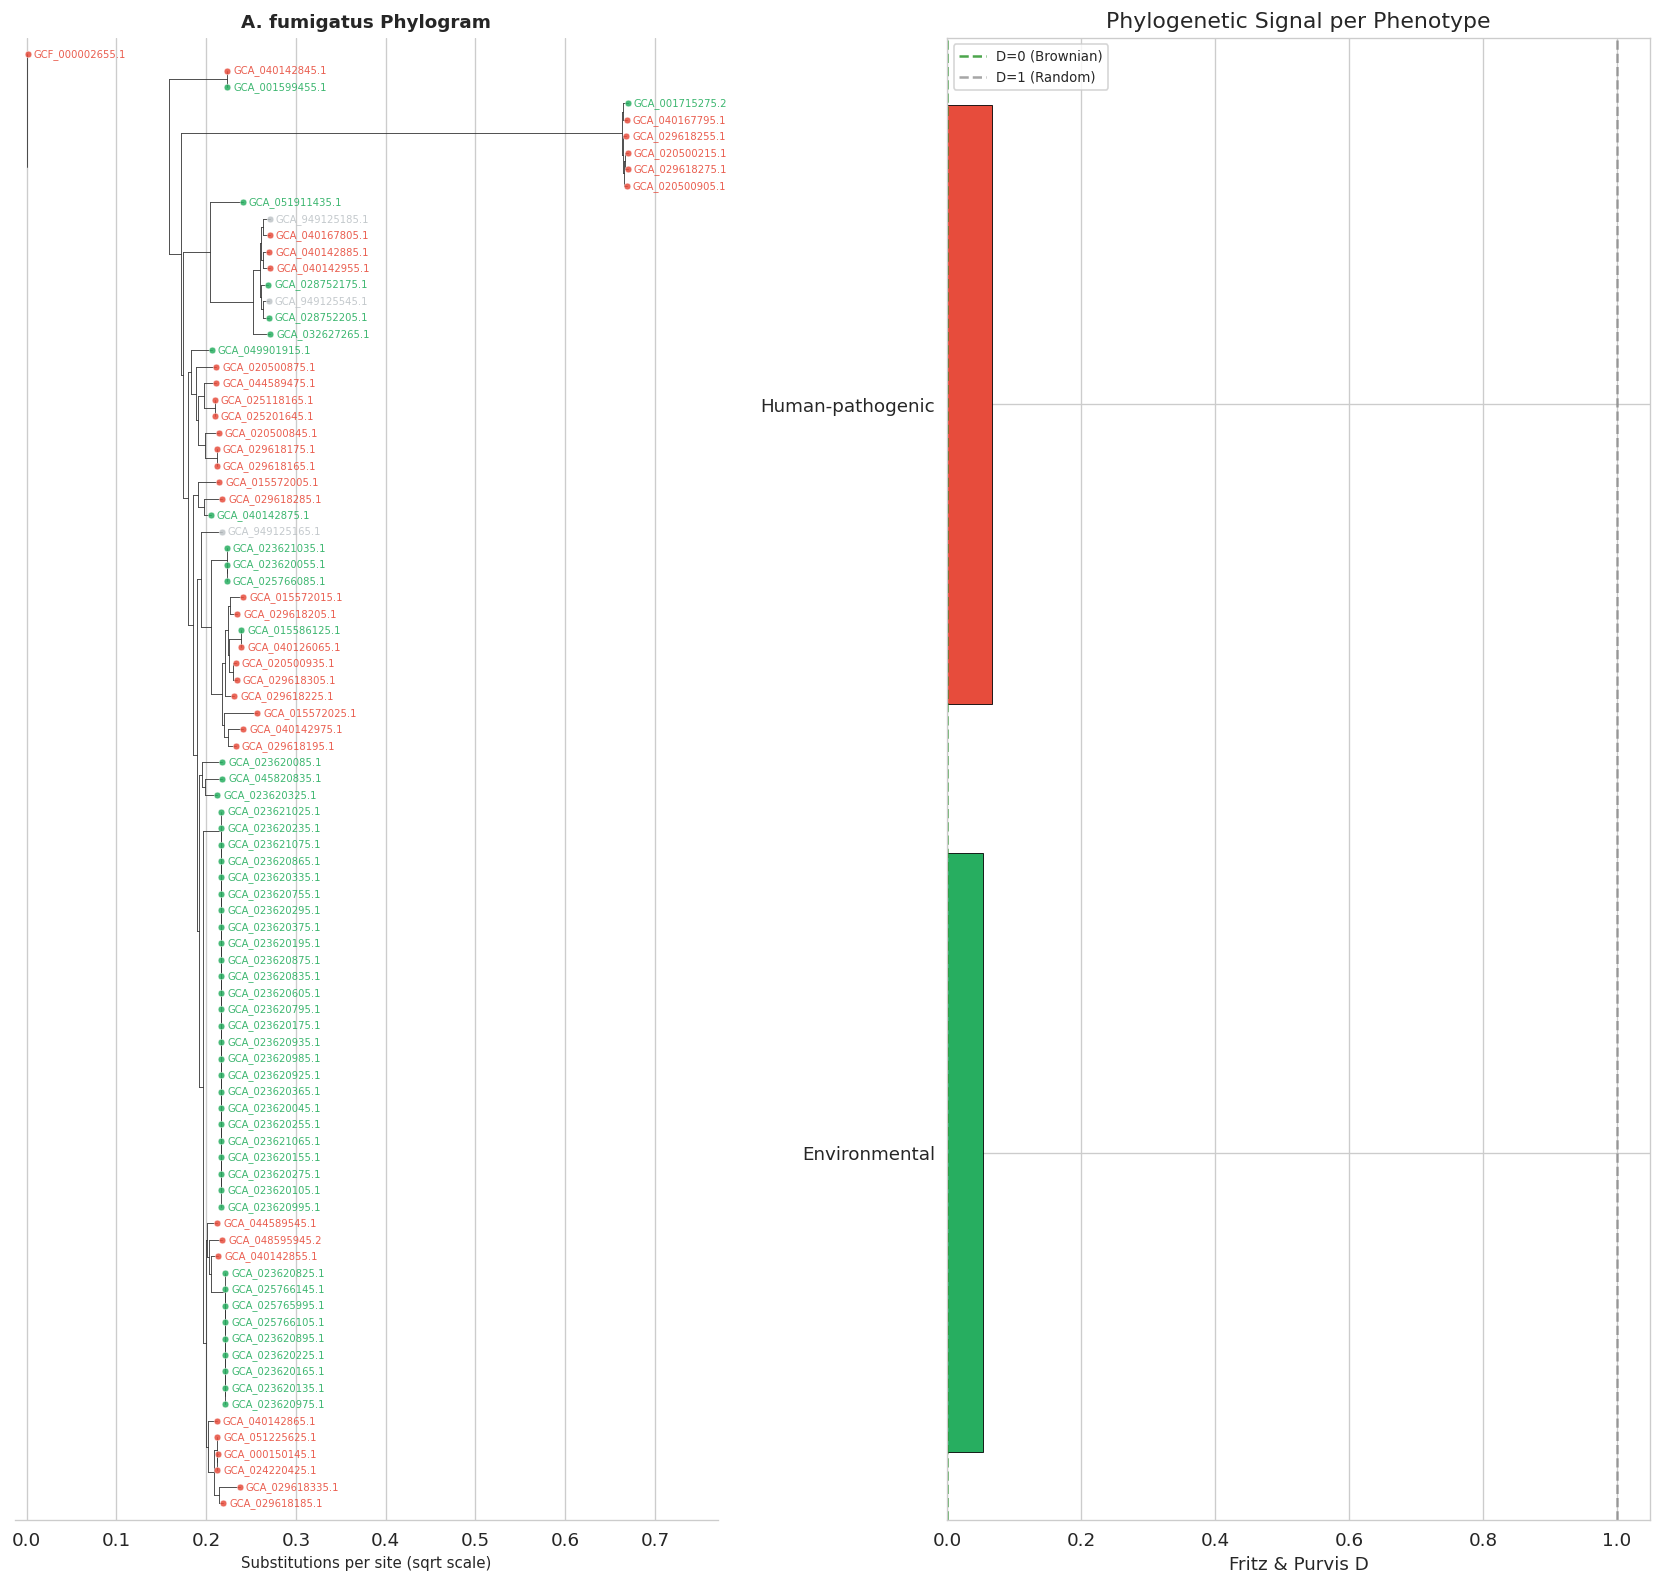

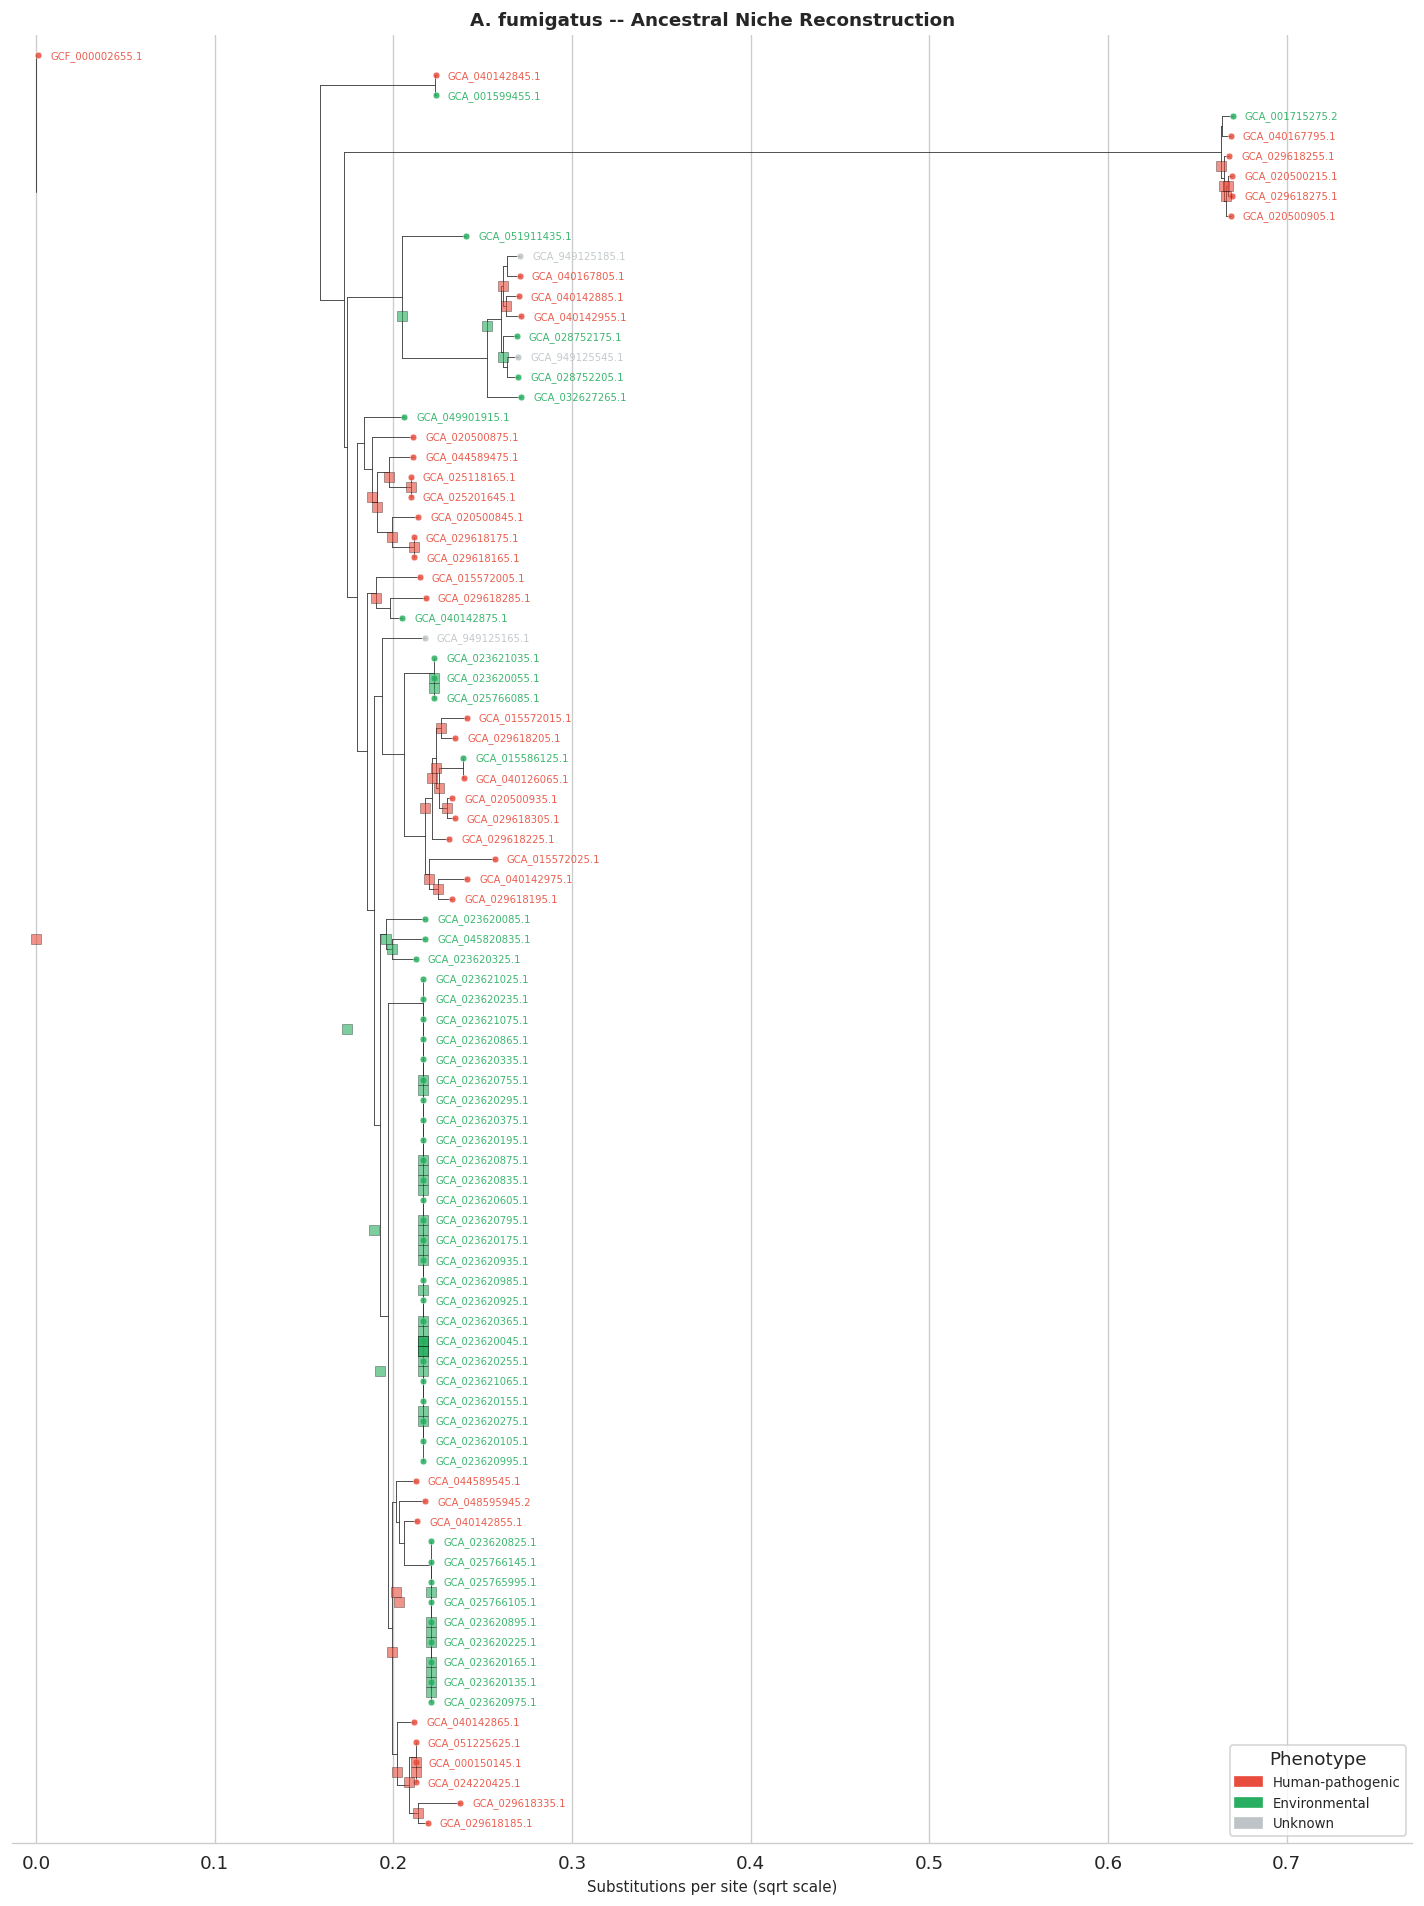

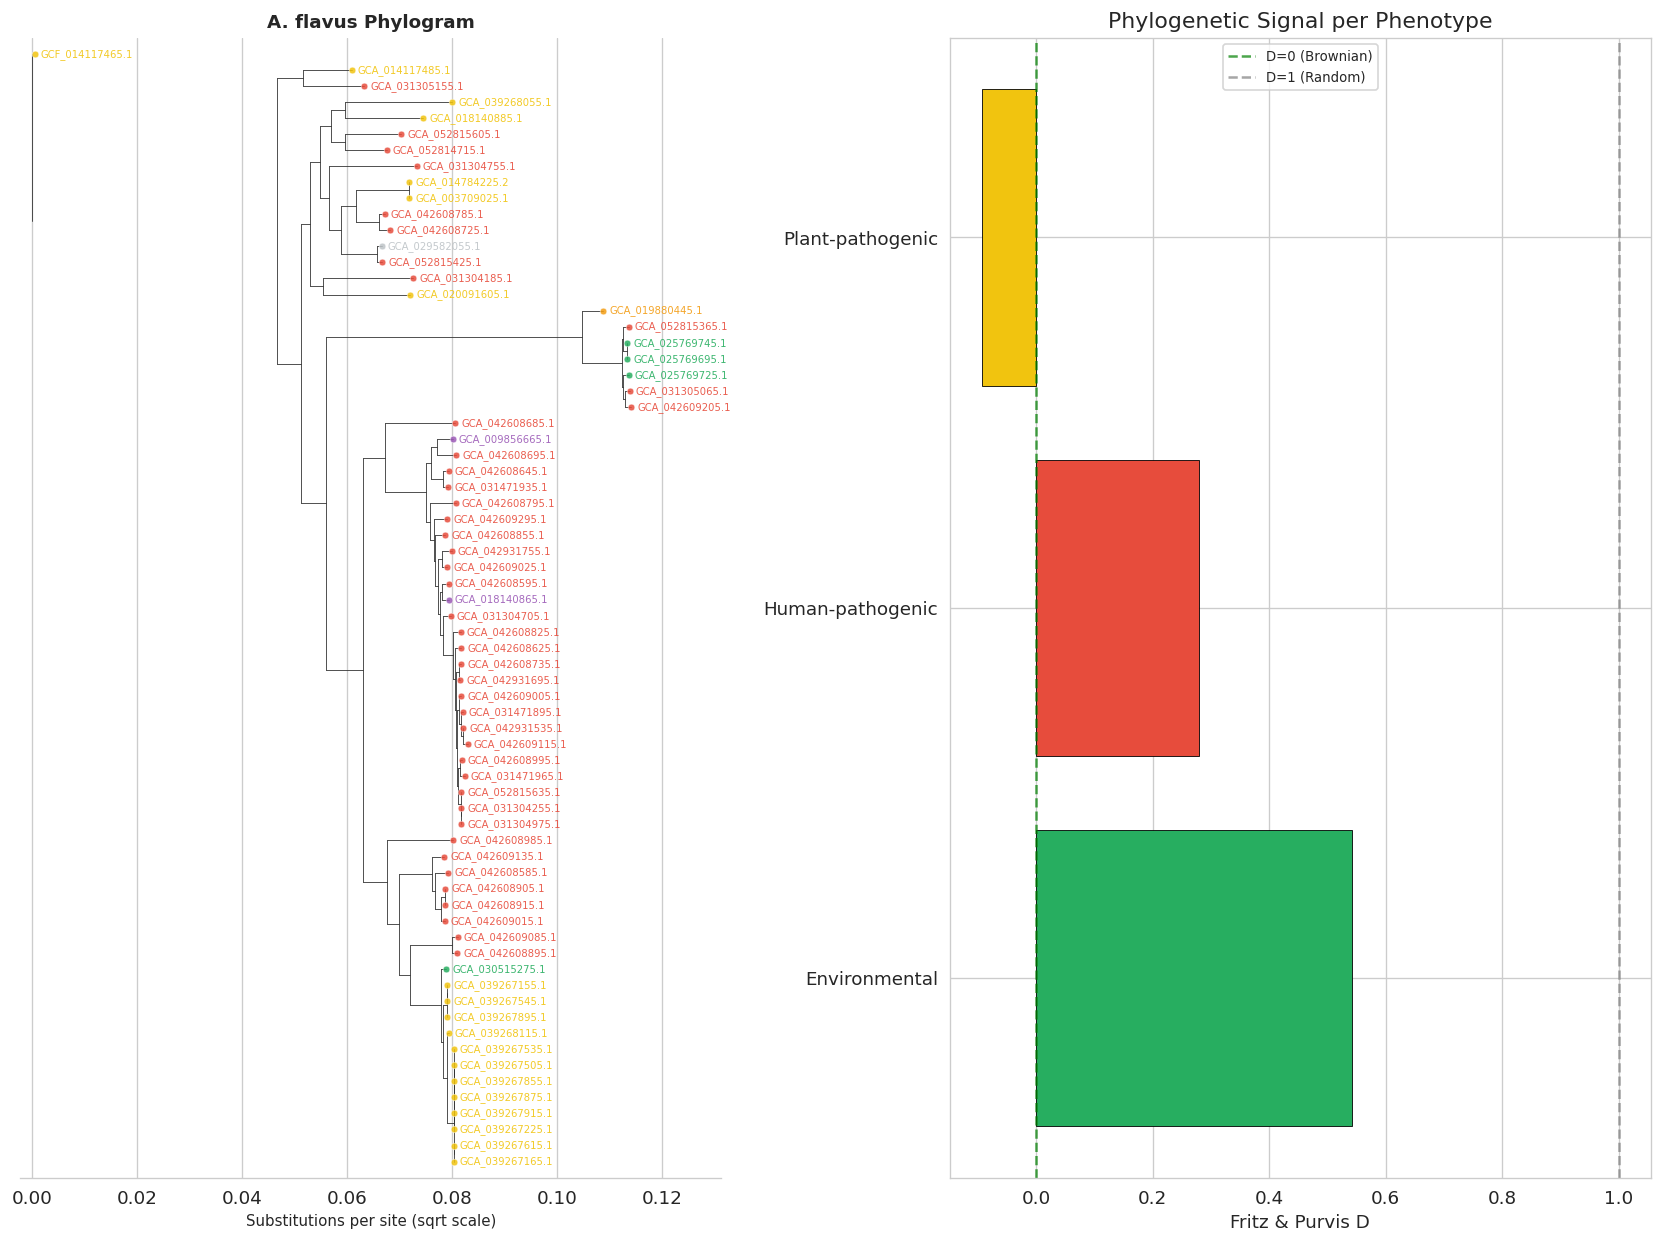

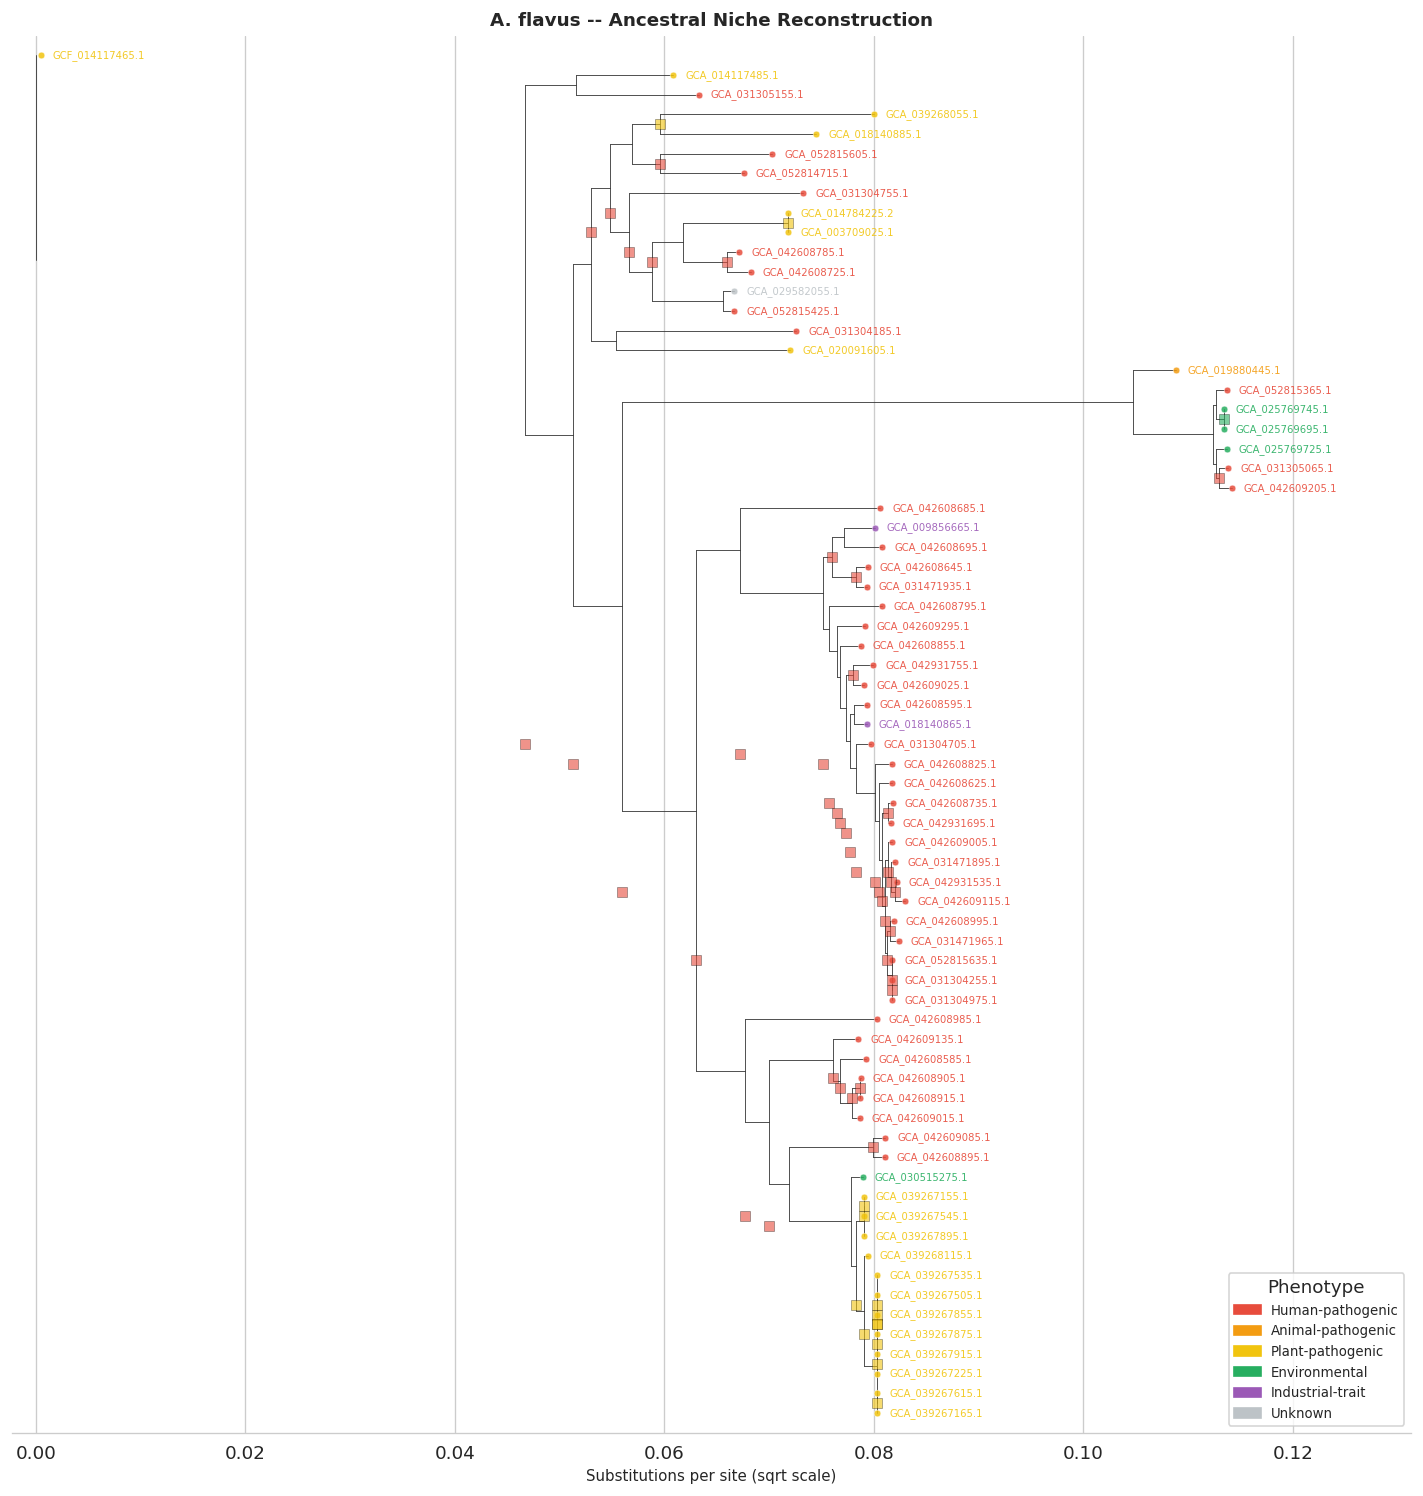

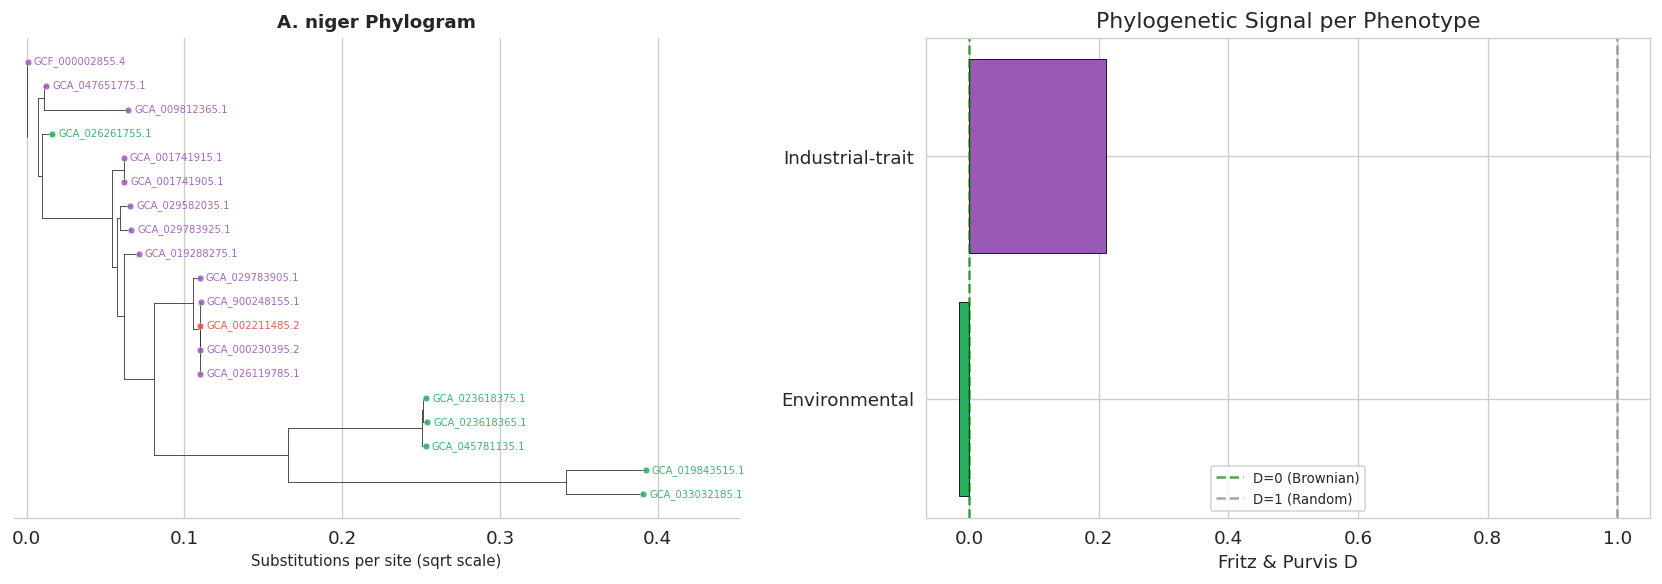

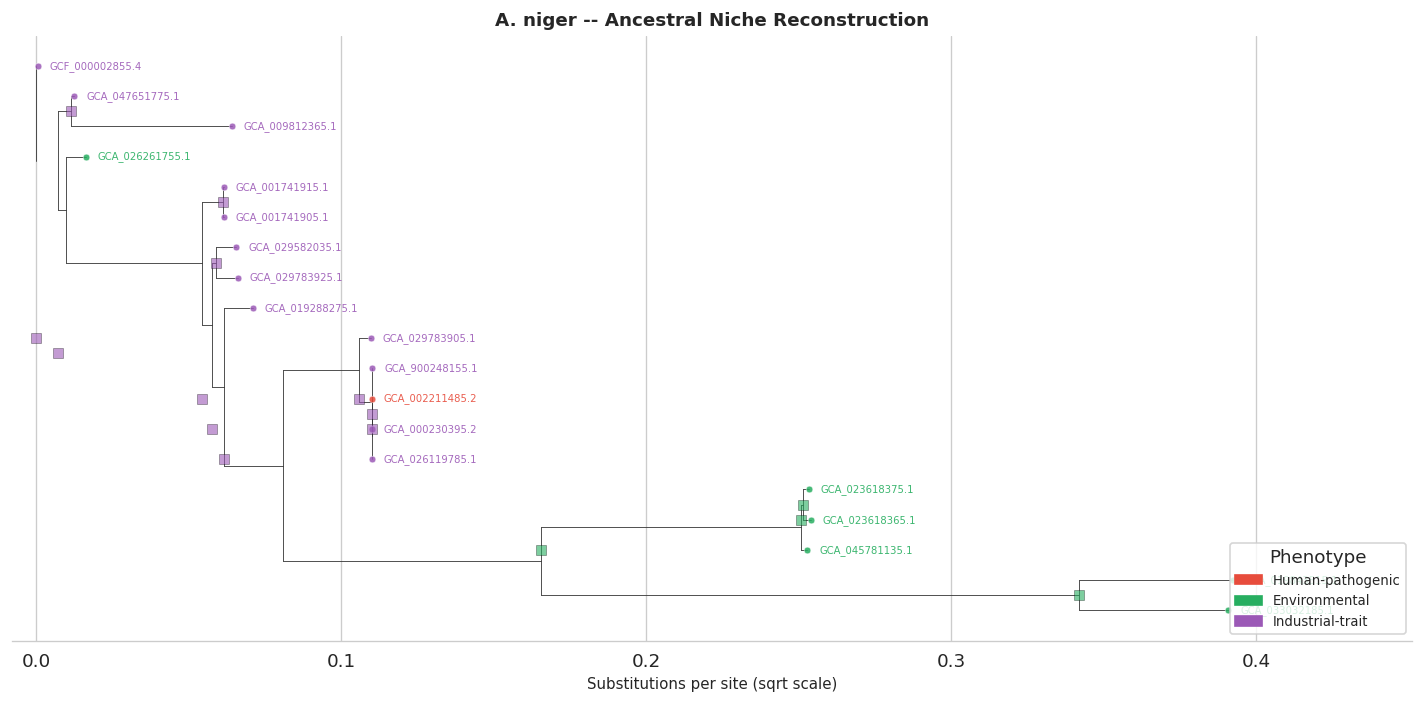

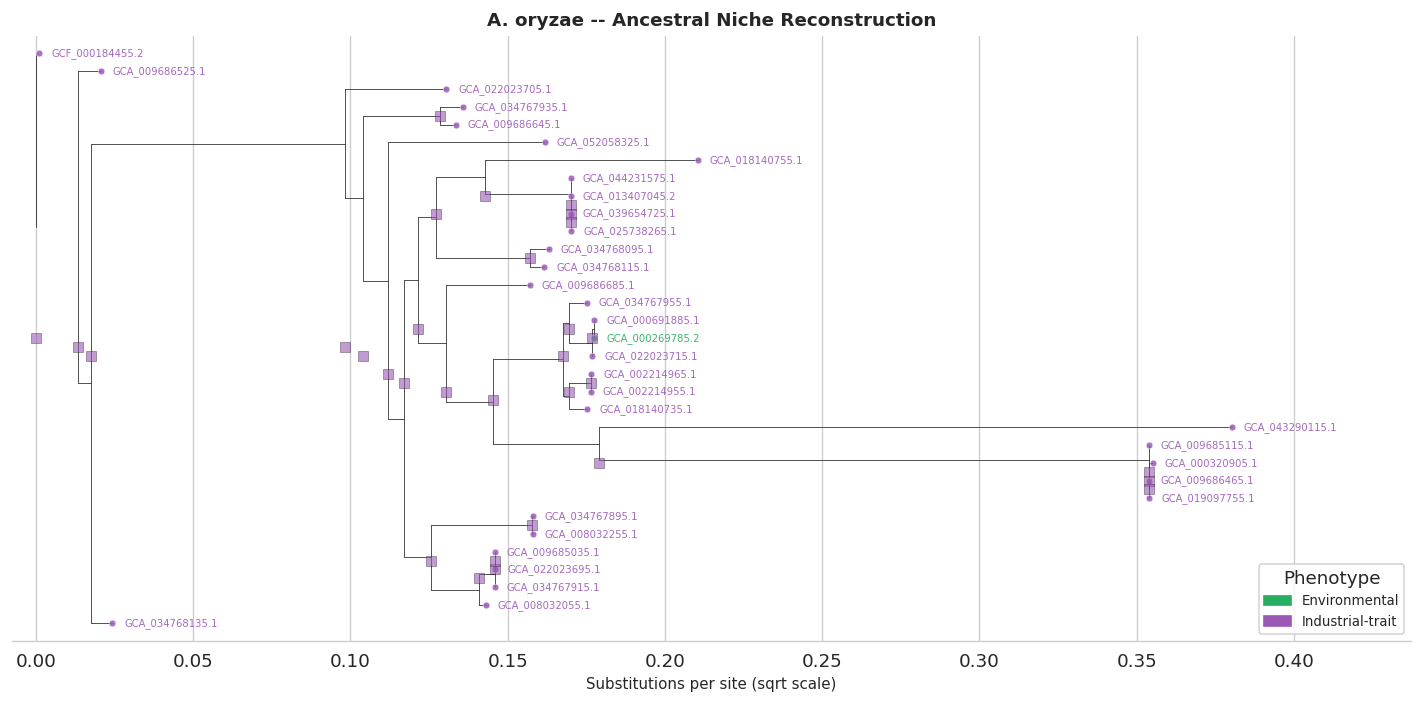

In [21]:
# --- Phylogenetic signal, gain/loss, and ancestral niche reconstruction ---
fphy.run_phylogenetic_analysis_all_species(
    SPECIES_LIST, species_data, SPECIES_CONFIG,
    pheno_map, pheno_df, RESULTS_DIR,
    genus=GENUS, ani_excluded=ANI_EXCLUDED, transform='sqrt'
)

---
## Section 10: Mash Clustering

Per-species Mash distance clustering + all-species combined clustering.

In [22]:
# --- 9.1 Per-species Mash distance clustering ---
SPECIES_LIST_MASH = ['fumigatus', 'flavus', 'niger', 'oryzae']
SPECIES_DISPLAY_MASH = {
    'fumigatus': 'A. fumigatus', 'flavus': 'A. flavus',
    'niger': 'A. niger', 'oryzae': 'A. oryzae',
}

# Load metadata for phenotype coloring
meta_path = os.path.join(NB0_RESULTS, 'qc_passed_classified_all.csv')
df_meta_mash = pd.read_csv(meta_path)
acc_to_phenotype = dict(zip(
    df_meta_mash['Assembly Accession'].str.extract(r'(GC[AF]_\d+\.\d+)')[0],
    df_meta_mash['Phenotype']
))

mash_results = fphy.run_mash_per_species(
    SPECIES_LIST_MASH, SPECIES_DISPLAY_MASH, GENUS, ANI_EXCLUDED, RESULTS_DIR
)


  A. fumigatus - Mash Distance Computation
  Found 89 genome files
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/fumigatus/fumigatus_distances.tsv
  Distance matrix shape: (89, 89)

  A. flavus - Mash Distance Computation
  Found 70 genome files
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/flavus/flavus_distances.tsv
  Distance matrix shape: (70, 70)

  A. niger - Mash Distance Computation
  Found 19 genome files
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/niger/niger_distances.tsv
  Distance matrix shape: (19, 19)

  A. oryzae - Mash Distance Computation
  Found 33 genome files
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/oryzae/oryzae_distances.tsv
  Distance matrix shape: (33, 33)

Per-species Mash distance computation complete!
  A. fumigatus: 89 genomes
  A. flavus: 70 genomes
  A. niger: 19 genomes


  A. fumigatus - Mash Clustering
  Optimal k=2 (silhouette peak k=2 close to elbow k=4; using silhouette)
  Cluster sizes:
    M1: 83
    M2: 6
  Saved heatmap: /datadrive/Analysis/NB4_Results/mash_clustering/fumigatus/fumigatus_mash_heatmap.pdf

  A. flavus - Mash Clustering
  Optimal k=5 (silhouette peak k=5 close to elbow k=4; using silhouette)
  Cluster sizes:
    M1: 13
    M2: 9
    M3: 6
    M4: 17
    M5: 25
  Saved heatmap: /datadrive/Analysis/NB4_Results/mash_clustering/flavus/flavus_mash_heatmap.pdf

  A. niger - Mash Clustering
  Optimal k=3 (silhouette peak k=5 too high for n=19 (avg cluster < 5); trusting elbow)
  Cluster sizes:
    M1: 3
    M2: 14
    M3: 2
  Saved heatmap: /datadrive/Analysis/NB4_Results/mash_clustering/niger/niger_mash_heatmap.pdf

  A. oryzae - Mash Clustering
  Optimal k=3 (silhouette peak k=15 too high for n=33 (avg cluster < 5); trusting elbow)
  Cluster sizes:
    M1: 21
    M2: 5
    M3: 7
  Saved heatmap: /datadrive/Analysis/NB4_Results/mash_c

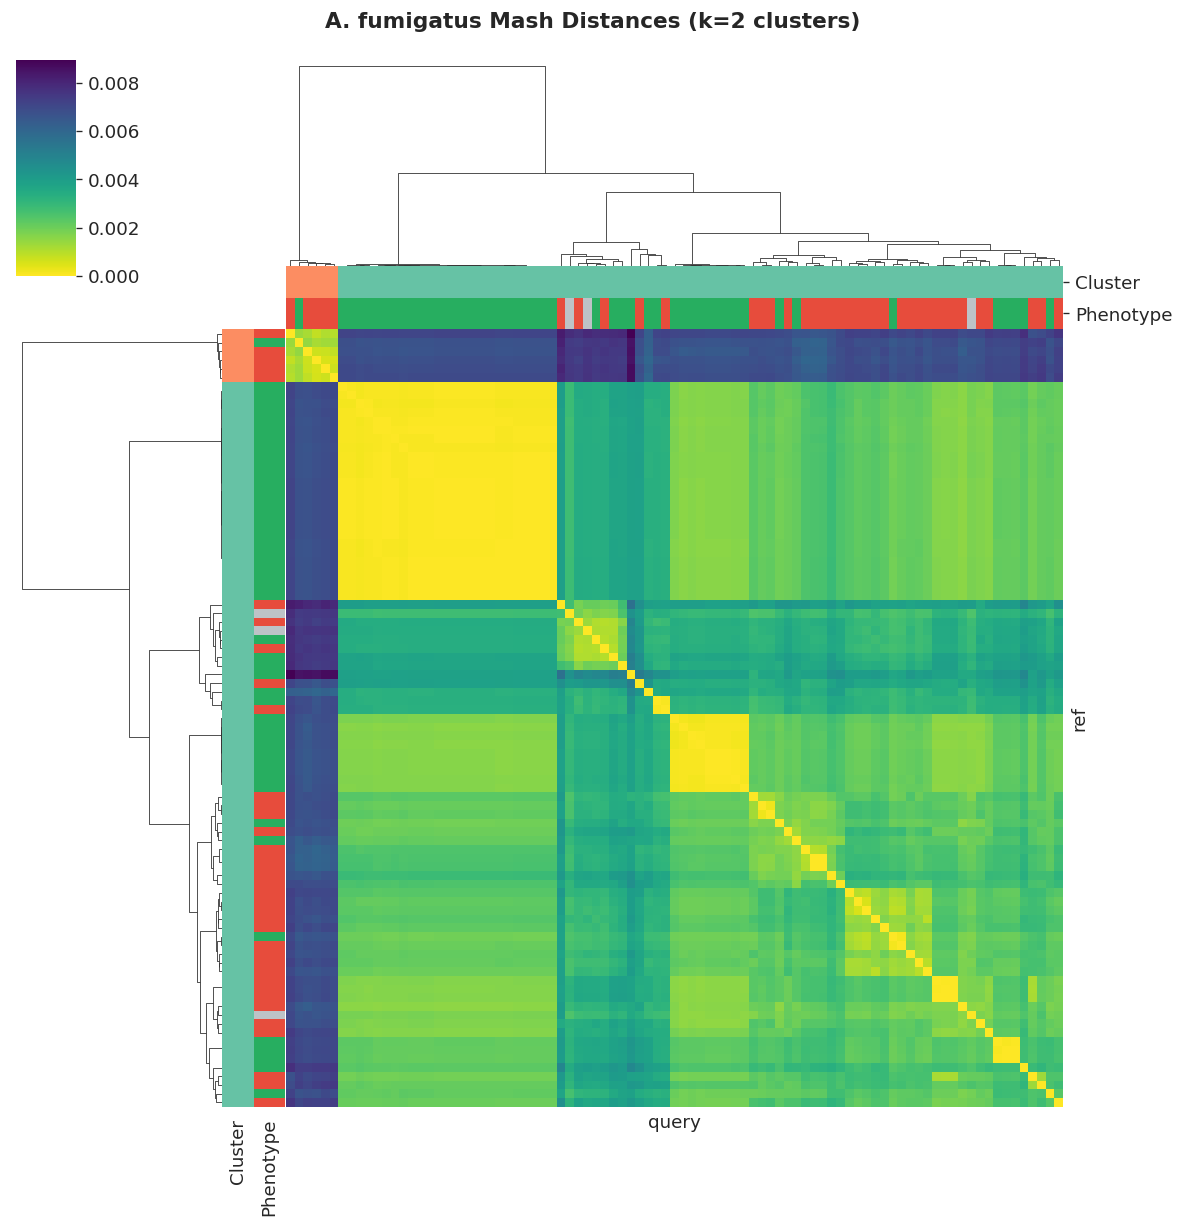

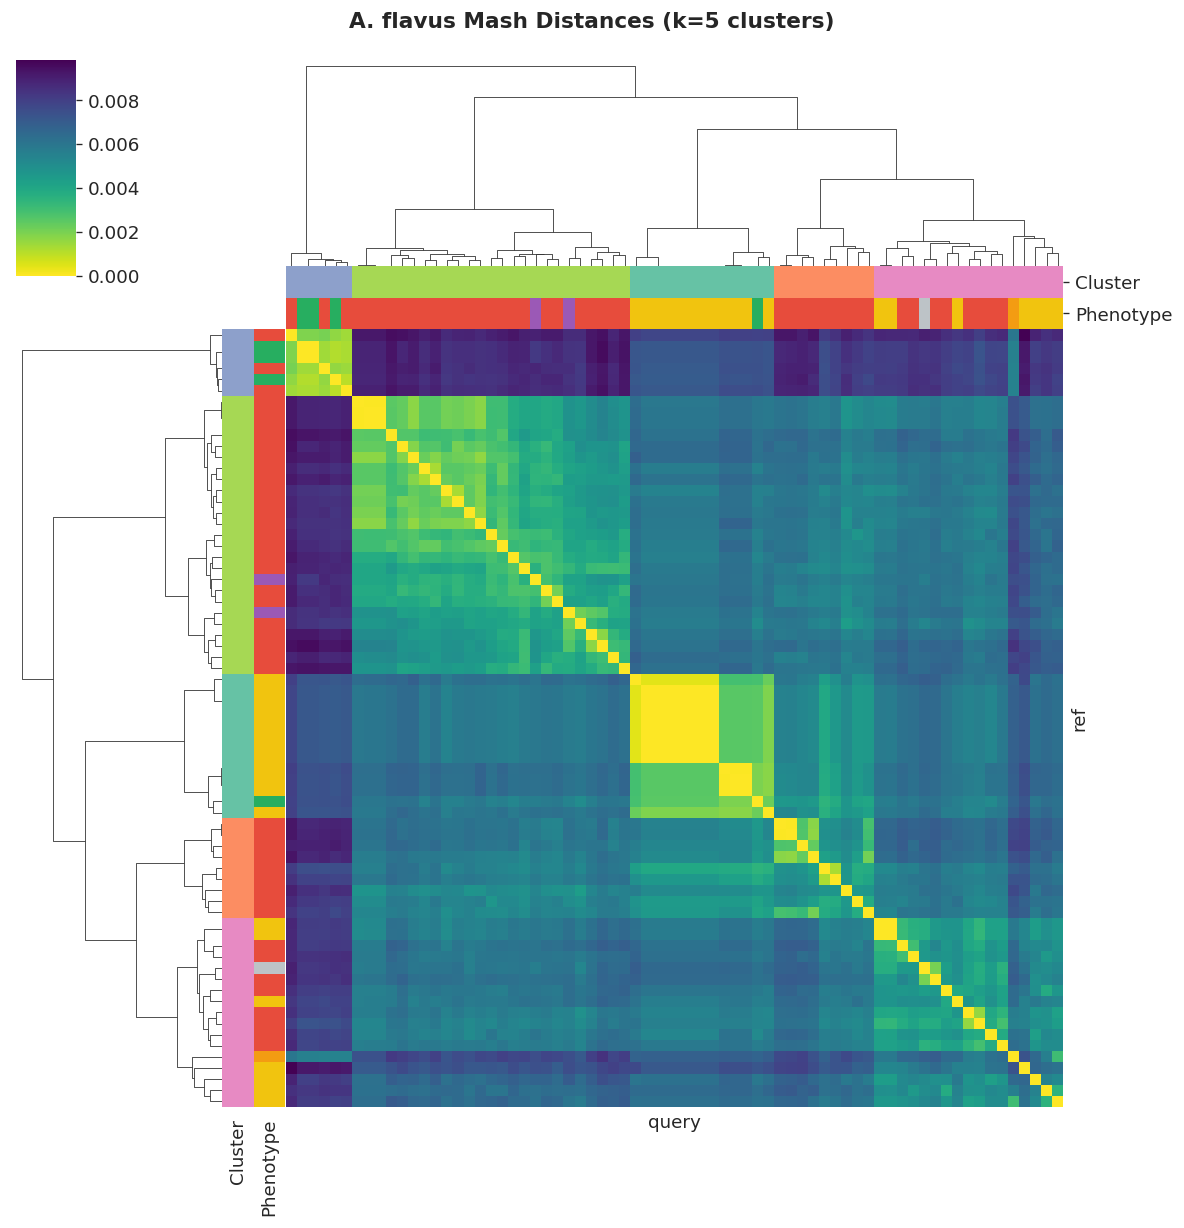

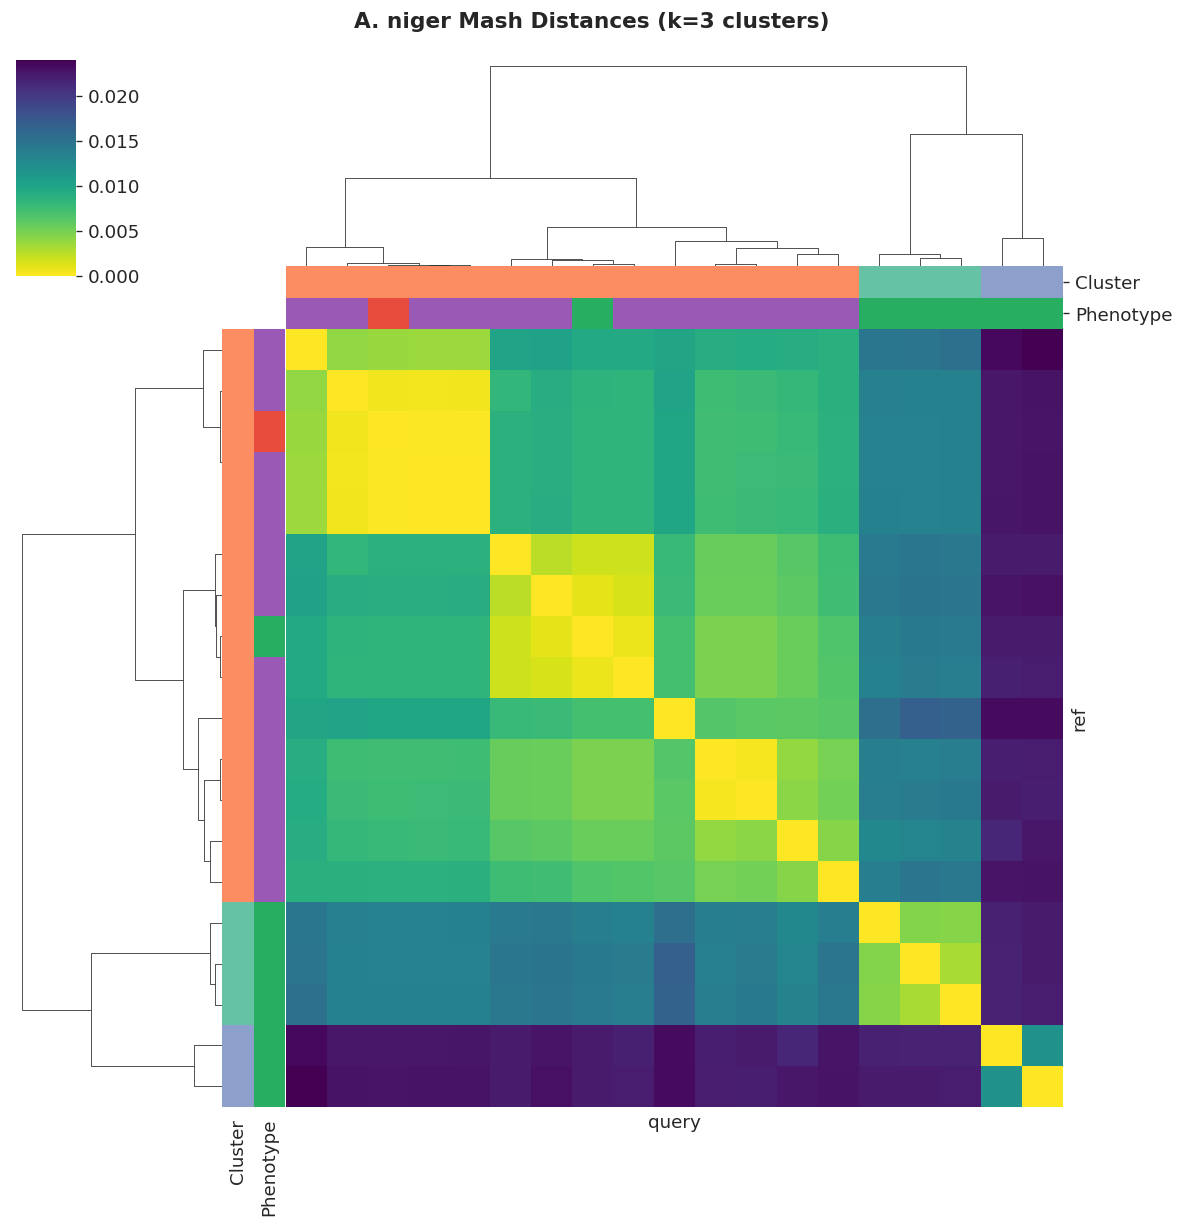

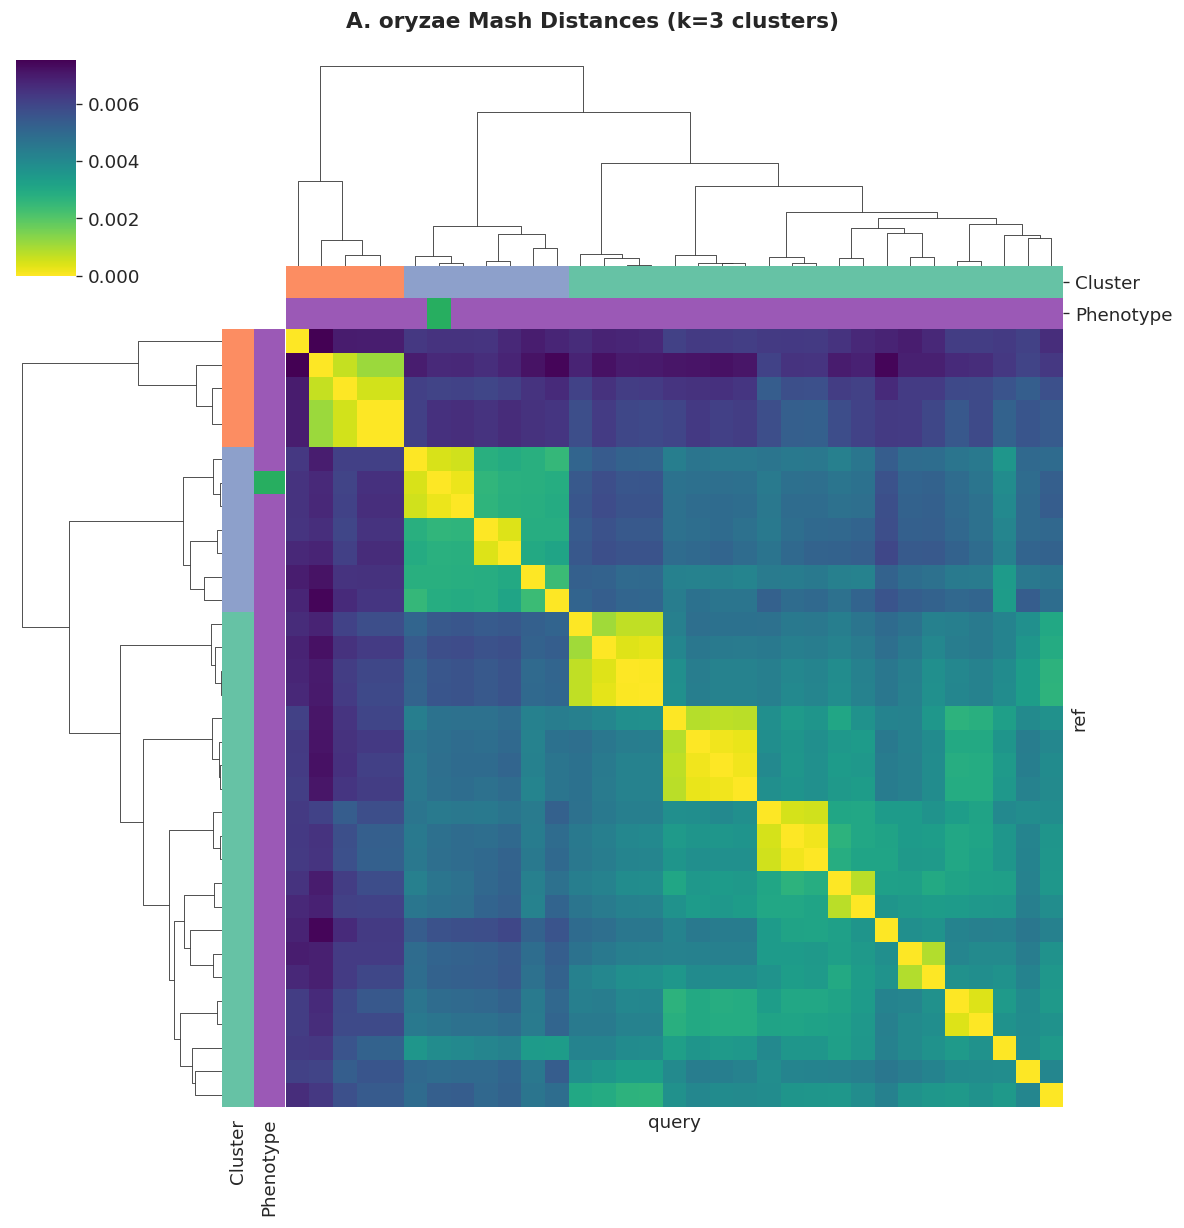

In [23]:
# --- 9.2 K-means clustering on Mash distances (per-species) ---
fphy.run_mash_kmeans(
    SPECIES_LIST_MASH, SPECIES_DISPLAY_MASH,
    mash_results, acc_to_phenotype, RESULTS_DIR
)

Total genomes across all species: 211
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/all_species/all_species_distances.tsv
Combined distance matrix: (211, 211)
Saved: /datadrive/Analysis/NB4_Results/mash_clustering/all_species/all_species_mash_heatmap.pdf
Saved: /datadrive/Analysis/NB4_Results/mash_clustering/all_species/all_species_genome_metadata.csv


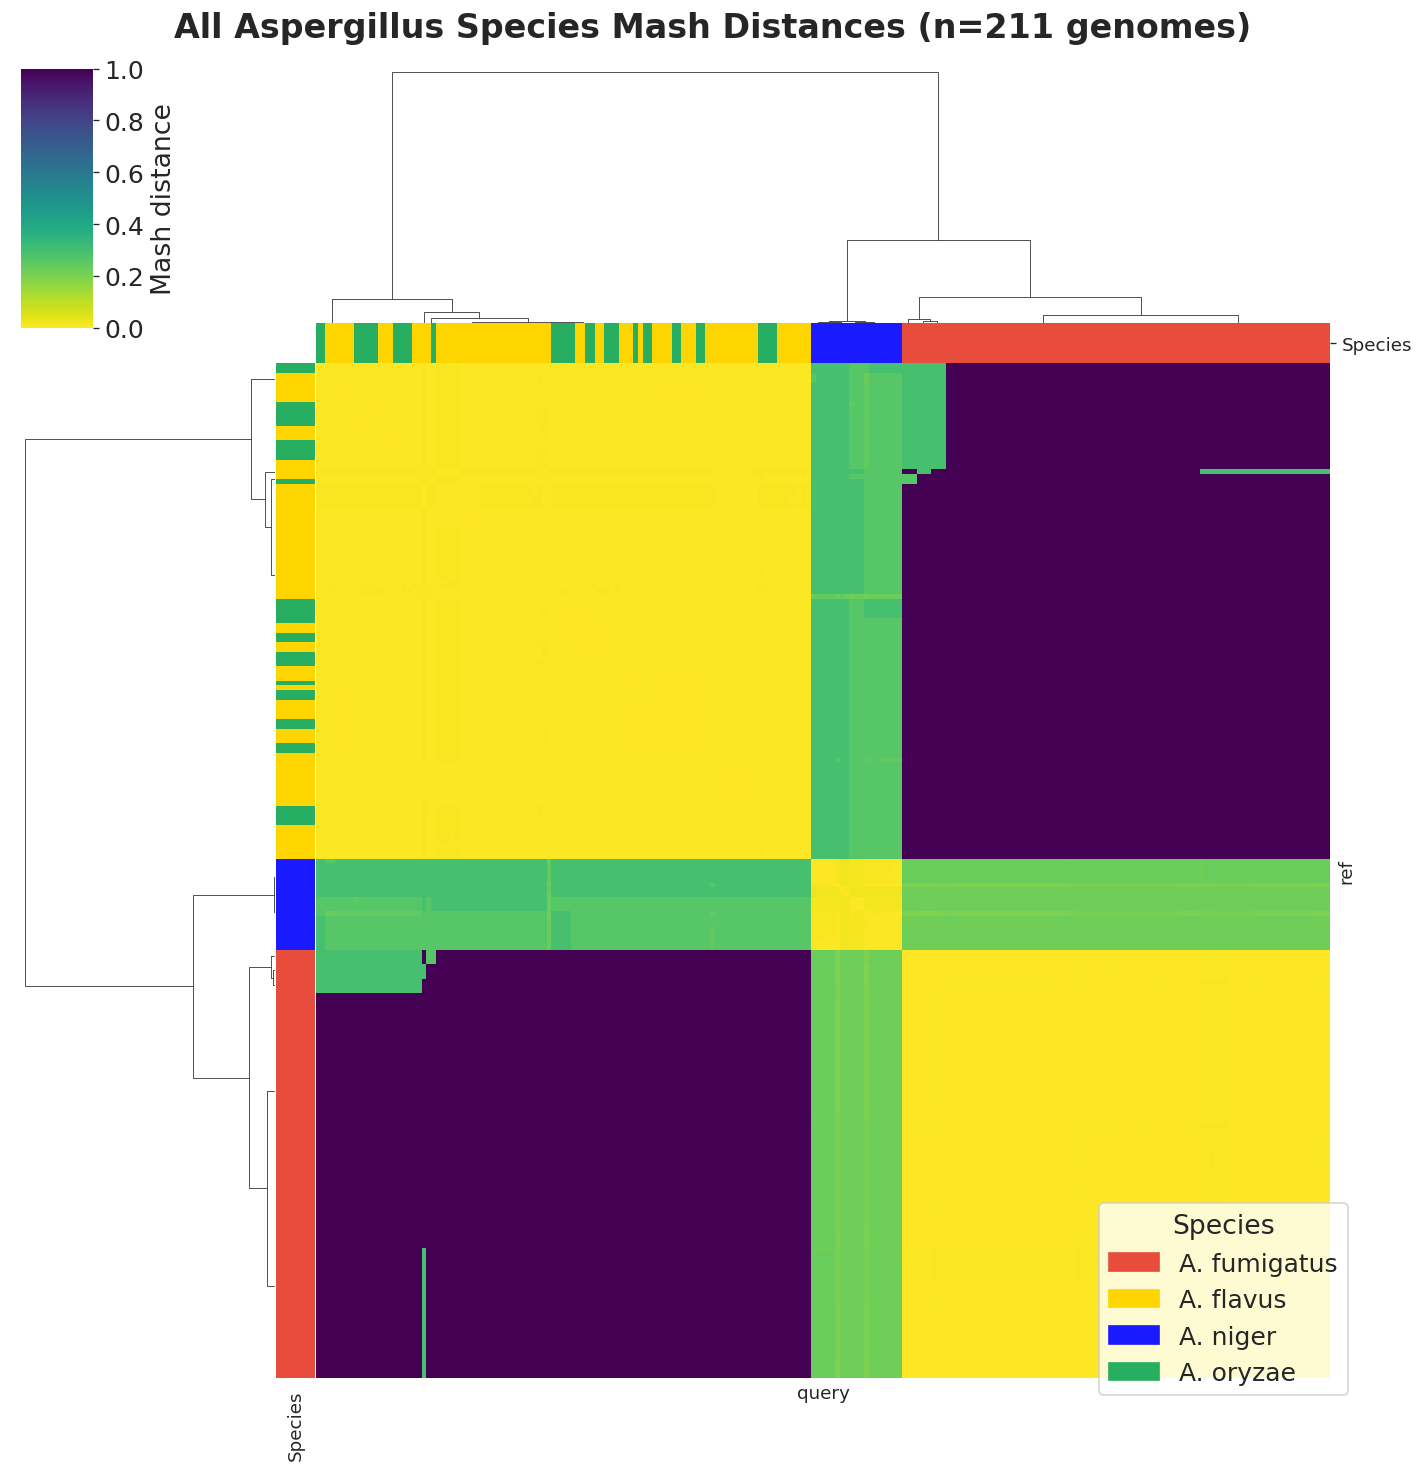

In [24]:
# --- 9.3 All-species combined Mash clustering ---
all_dist_matrix = fphy.run_mash_all_species(
    SPECIES_LIST_MASH, SPECIES_DISPLAY_MASH,
    GENUS, ANI_EXCLUDED, acc_to_phenotype, RESULTS_DIR
)

### All-species Mash whole-genome distance clustering

Hierarchically clustered heatmap (Ward linkage) of pairwise Mash *k*-mer
distances among all 211 QC-passed genomes (*A. fumigatus* n = 89,
*A. flavus* n = 70, *A. oryzae* n = 33, *A. niger* n = 19), with side colour
bars marking species. Yellow indicates near-identical genomes and dark purple
maximal divergence. *A. fumigatus* forms a single tight block and *A. niger* a
small, well-separated group, whereas *A. flavus* and *A. oryzae* collapse into
one shared low-distance block &mdash; the Mash sketch (*k* = 21, sketch size
1,000) treats them as effectively one lineage because it does not resolve the
gene presence/absence and copy-number remodelling that distinguishes
domesticated *A. oryzae* from its *A. flavus* progenitor.

---
## Summary

All rare genome and phylogenetic outputs have been written to `NB4_Results/`:

| File | Description |
|------|-------------|
| `rare_genome_summary.csv` | Rare OG counts per species |
| `oryzae_rare_orthogroups_detailed.csv` | Deep annotation of 6 A. oryzae rare OGs |
| `niger_rare_orthogroups.csv` | A. niger rare OG annotations |
| `cog_enrichment_rare_vs_nonrare.csv` | Fisher's test COG enrichment |
| `annotation_rates_by_class.csv` | Annotation rates by pangenome class |
| `rare_gene_burden_by_phenotype.csv` | Mann-Whitney U burden tests |
| `rare_gene_burden_all_genomes.csv` | Per-genome burden table |
| `rare_genome_characterisation_figure.png/pdf` | Multi-panel characterization figure |
| `rare_gene_characterisation_summary.csv` | Length/annotation summary |
| `rare_xenolog_ncbi_blast_results.tsv` | NCBI BLAST xenolog candidates |
| `{species}/phylogenetic_signal.png` | Fritz & Purvis D per phenotype |
| `{species}/ancestral_niche_reconstruction.png` | Fitch parsimony niche reconstruction |
| `{species}/gain_loss_events.tsv` | Per-OG parsimony change counts |
| `{species}/gain_loss_summary.tsv` | Gain/loss summary statistics |
| `mash_clustering/{species}/` | Per-species Mash distances + clusters |
| `mash_clustering/all_species/` | Combined 4-species Mash analysis |

---
## Section 10: Rare-genome summary figures (add-on)

(a) DIAMOND classification of rare OGs per species; (b) per-genome rare-gene burden by species x phenotype; (c) truly-rare COG characterisation per species; (d) truly-rare gene burden by phenotype.


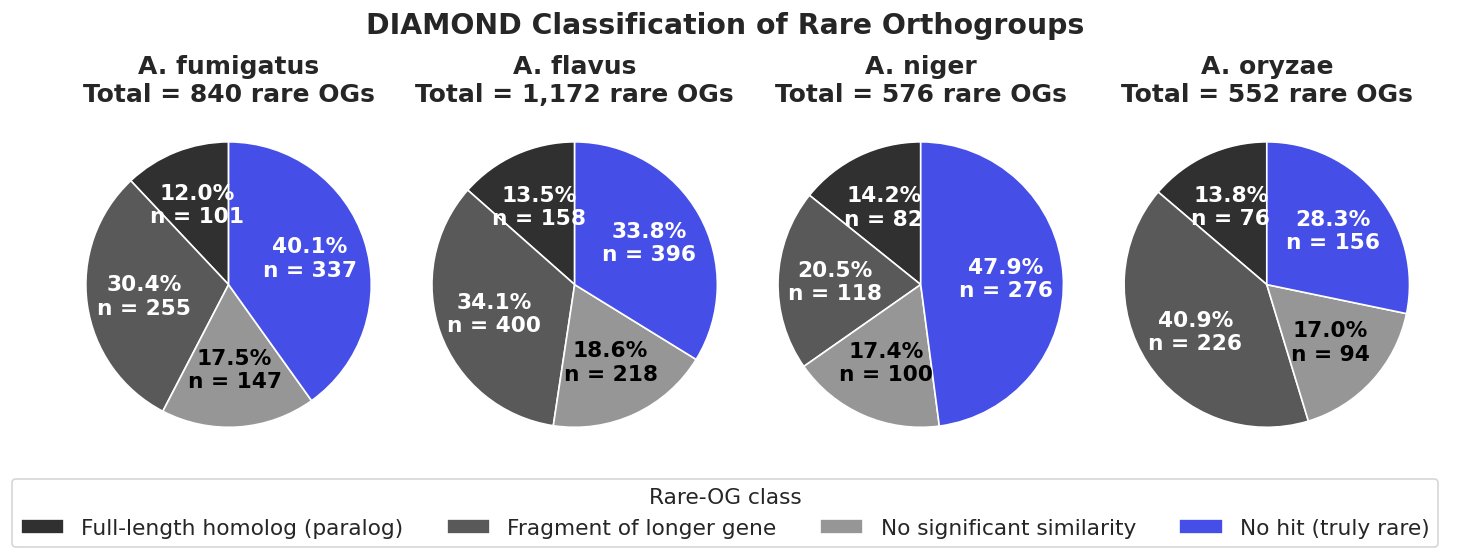

Saved -> /datadrive/Analysis/NB4_Results/diamond_classification_pies.png  (+ .pdf)


In [25]:
# --- (a) DIAMOND blastp classification of rare OGs: pie per species ---
# 1x4 row of pies from diamond_classification_summary.csv. Each rare OG was
# BLASTed against its own species' Core+Accessory pool and classified as
# Full-length homolog / Fragment / No-significant-similarity / No-hit
# (the No-hit class = the truly lineage-private subset).
# --- Tweakable parameters ---
FS_DP, DPI_DP = 15, 400
FIG_W_DP, FIG_H_DP = 15.0, 4.6
# Alpha for the 3 NON-truly-rare classes (homolog/fragment/no-sim);
# the 'No hit' truly-rare wedge always stays fully opaque (1.0).
NONTRULY_ALPHA = 1.0   # 1.0 = no fade

from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
NB4_RESULTS = Path('/datadrive/Analysis/NB4_Results')

_path = NB4_RESULTS / 'diamond_classification_summary.csv'
if not _path.exists():
    print(f'No DIAMOND summary at {_path}.')
else:
    d = pd.read_csv(_path)
    classes = ['Full-length homolog', 'Fragment of longer gene',
               'No significant similarity', 'No hit']
    short   = ['Full-length homolog (paralog)', 'Fragment of longer gene',
               'No significant similarity', 'No hit (truly rare)']
    colors  = ["#313030", '#595959', '#969696', "#464ee8"]  # black -> light grey ramp

    fig, axes = plt.subplots(1, 4, figsize=(FIG_W_DP, FIG_H_DP),
                             gridspec_kw=dict(wspace=-0.03))
    for ax, (_, row) in zip(axes.ravel(), d.iterrows()):
        sizes  = [int(row[c]) for c in classes]
        wedges, _t, autotxts = ax.pie(
            sizes, labels=None, colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=dict(linewidth=1.0, edgecolor='white'),
            textprops=dict(fontsize=FS_DP - 2))
        # De-emphasise the 3 non-truly-rare wedges; keep "No hit" solid.
        for wi, wedge in enumerate(wedges):
            wedge.set_alpha(1.0 if wi == 3 else NONTRULY_ALPHA)
        # % text inside each wedge: white on dark slices, black on light slices
        for tt, col, n in zip(autotxts, colors, sizes):
            lum = int(col.lstrip('#')[0:2], 16)   # grey ramp -> R==G==B
            tt.set_color('white' if lum < 128 else 'black')
            tt.set_fontsize(FS_DP - 2); tt.set_fontweight('bold')
            tt.set_text(f'{tt.get_text()}\nn = {n:,}')   # move n= inside the wedge
        ax.set_aspect('equal')
        ax.set_title(f"{row['Species']}\n"
                     f"Total = {int(row['Total']):,} rare OGs",
                     fontsize=FS_DP, fontweight='bold', pad=3)
    # One shared legend at the bottom-right of the figure
    handles = [Patch(facecolor=c, edgecolor='white', label=s)
               for c, s in zip(colors, short)]
    fig.legend(handles=handles, title='Rare-OG class',
               loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=4,
               fontsize=FS_DP - 2, title_fontsize=FS_DP - 2, frameon=True)
    fig.suptitle('DIAMOND Classification of Rare Orthogroups',
                 fontsize=FS_DP + 2, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0.14, 1, 0.92])
    out = NB4_RESULTS / 'diamond_classification_pies.png'
    fig.savefig(out, dpi=DPI_DP, bbox_inches='tight')
    fig.savefig(out.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}  (+ .pdf)')


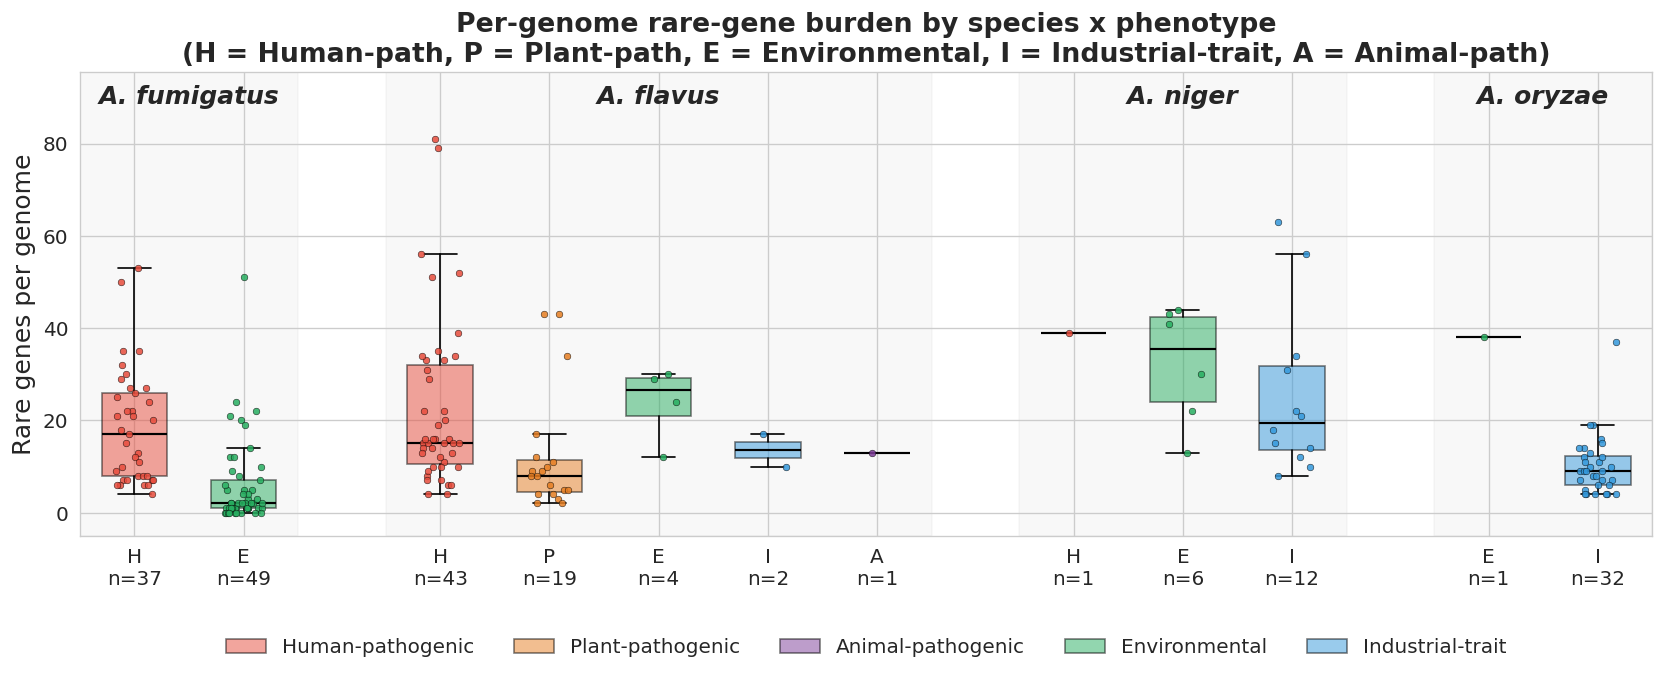

Saved -> /datadrive/Analysis/NB4_Results/rare_burden_by_species_phenotype.png  (+ .pdf)


In [26]:
# --- (b) Per-genome rare-gene burden by species x phenotype ---
# Box-strip plot from rare_gene_burden_all_genomes.csv -- same layout as
# Figure 4a: grouped per species, one box per phenotype.
# --- Tweakable parameters ---
FS_RB, DPI_RB = 15, 400
FIG_W_RB, FIG_H_RB = 14.0, 6.0

from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Patch
NB4_RESULTS = Path('/datadrive/Analysis/NB4_Results')
SPECIES_ORDER = ['fumigatus', 'flavus', 'niger', 'oryzae']
# Phenotype palette = NB0 phenotype-distribution colours
# (funpan_utils.plot_phenotype_distribution -> UNIFIED_COLORS)
PHENO_COLORS = {'Human-pathogenic': '#e74c3c', 'Plant-pathogenic': '#e67e22',
                'Animal-pathogenic': '#7d3c98', 'Environmental': '#27ae60',
                'Industrial-trait': '#3498db'}
PHENO_ORDER = ['Human-pathogenic', 'Plant-pathogenic', 'Environmental',
               'Industrial-trait', 'Animal-pathogenic']

_path = NB4_RESULTS / 'rare_gene_burden_all_genomes.csv'
if not _path.exists():
    print(f'No burden table at {_path}.')
else:
    burden = pd.read_csv(_path)
    burden = burden[burden['Phenotype'].isin(PHENO_ORDER)]
    fig, ax = plt.subplots(figsize=(FIG_W_RB, FIG_H_RB))
    pos, positions, labels, bounds, all_vals = 0, [], [], [], []
    for sp in SPECIES_ORDER:
        sub = burden[burden['Species'] == f'A. {sp}']
        sp_phs = [p for p in PHENO_ORDER if p in sub['Phenotype'].unique()]
        start = pos
        for ph in sp_phs:
            vals = sub[sub['Phenotype'] == ph]['Rare_genes'].values
            if len(vals) == 0:
                continue
            all_vals.extend(vals)
            ax.boxplot([vals], positions=[pos], widths=0.6, showfliers=False,
                       patch_artist=True,
                       boxprops=dict(facecolor=PHENO_COLORS[ph], alpha=0.5,
                                     edgecolor='black'),
                       medianprops=dict(color='black', linewidth=1.3))
            jit = np.random.RandomState(42).uniform(-0.18, 0.18, len(vals))
            ax.scatter([pos] * len(vals) + jit, vals, s=16,
                       color=PHENO_COLORS[ph], alpha=0.85,
                       edgecolor='black', linewidth=0.3, zorder=3)
            positions.append(pos)
            labels.append(f'{ph[0]}\nn={len(vals)}')
            pos += 1
        bounds.append((start - 0.5, pos - 0.5, f'A. {sp}'))
        pos += 0.8
    ymax = max(all_vals) * 1.18
    ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=FS_RB - 3)
    ax.set_ylim(-5, ymax)
    for lo, hi, sp in bounds:
        ax.text((lo + hi) / 2, ymax * 0.97, sp, ha='center', va='top',
                fontweight='bold', fontstyle='italic', fontsize=FS_RB)
        ax.axvspan(lo, hi, color='grey', alpha=0.05, zorder=0)
    ax.set_ylabel('Rare genes per genome', fontsize=FS_RB)
    ax.tick_params(axis='y', labelsize=FS_RB - 3)
    ax.set_title('Per-genome rare-gene burden by species x phenotype\n'
                 '(H = Human-path, P = Plant-path, E = Environmental, '
                 'I = Industrial-trait, A = Animal-path)',
                 fontsize=FS_RB + 1, fontweight='bold')
    ax.legend(handles=[Patch(facecolor=c, edgecolor='black', alpha=0.5, label=p)
                       for p, c in PHENO_COLORS.items()],
              frameon=False, fontsize=FS_RB - 3, ncol=5,
              loc='lower center', bbox_to_anchor=(0.5, -0.30))
    plt.tight_layout()
    out = NB4_RESULTS / 'rare_burden_by_species_phenotype.png'
    fig.savefig(out, dpi=DPI_RB, bbox_inches='tight')
    fig.savefig(out.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}  (+ .pdf)')

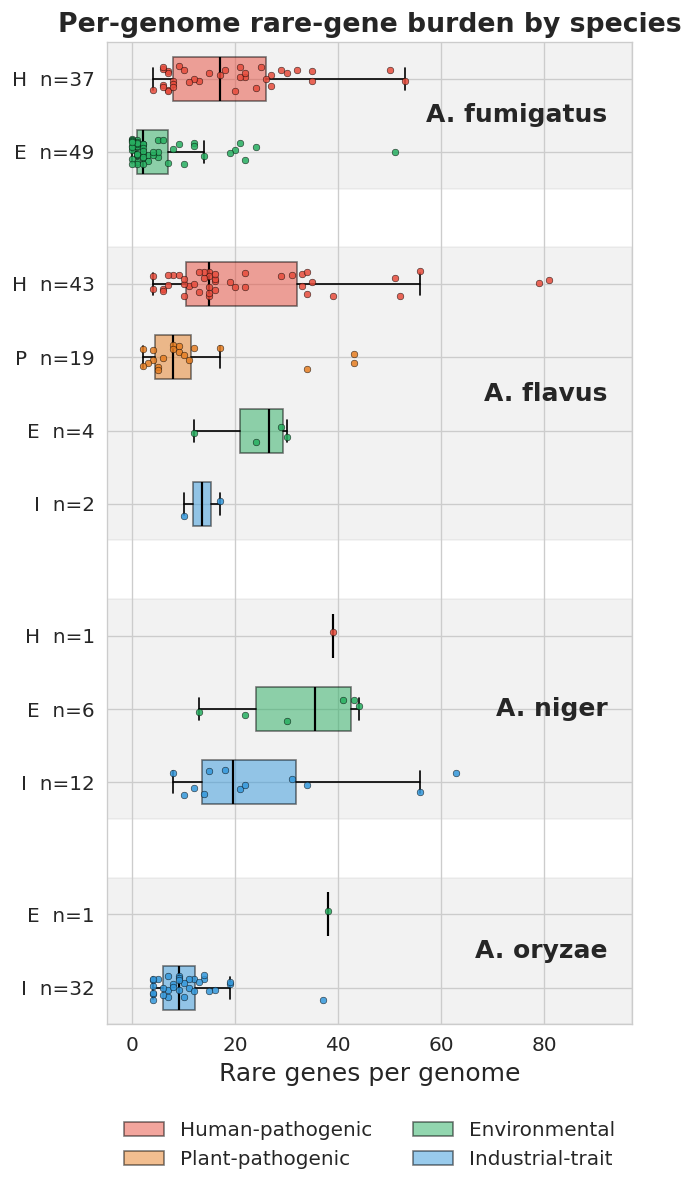

Saved -> /datadrive/Analysis/NB4_Results/rare_burden_by_species_phenotype_vertical.png  (+ .pdf)


In [27]:
# --- (b) Per-genome rare-gene burden by species x phenotype (VERTICAL) ---
FS_RB_V, DPI_RB_V = 15, 400
FIG_W_RB_V, FIG_H_RB_V = 5.5, 10.0

# Local definitions so this cell doesn't depend on prior-cell state.
SPECIES_ORDER_V = ['A. fumigatus', 'A. flavus', 'A. niger', 'A. oryzae']
PHENO_ORDER_V   = ['Human-pathogenic', 'Plant-pathogenic',
                   'Environmental', 'Industrial-trait']  # animal-path dropped (n=1)

_path = NB4_RESULTS / 'rare_gene_burden_all_genomes.csv'
if not _path.exists():
    print(f'No burden table at {_path}.')
else:
    burden = pd.read_csv(_path)
    burden['Species']   = burden['Species'].astype(str).str.strip()
    burden['Phenotype'] = burden['Phenotype'].astype(str).str.strip()
    burden = burden[burden['Phenotype'].isin(PHENO_ORDER_V)]

    fig, ax = plt.subplots(figsize=(FIG_W_RB_V, FIG_H_RB_V))
    pos, positions, labels, bounds, all_vals = 0, [], [], [], []
    for sp in SPECIES_ORDER_V:
        sub = burden[burden['Species'] == sp]
        sp_phs = [p for p in PHENO_ORDER_V if p in set(sub['Phenotype'])]
        start = pos
        for ph in sp_phs:
            vals = sub.loc[sub['Phenotype'] == ph, 'Rare_genes'].to_numpy()
            if len(vals) == 0:
                continue
            all_vals.extend(vals)
            ax.boxplot([vals], positions=[pos], widths=0.6, showfliers=False,
                       vert=False, patch_artist=True,
                       boxprops=dict(facecolor=PHENO_COLORS[ph], alpha=0.5,
                                     edgecolor='black'),
                       medianprops=dict(color='black', linewidth=1.3),
                       whiskerprops=dict(color='black'),
                       capprops=dict(color='black'))
            jit = np.random.RandomState(42).uniform(-0.18, 0.18, len(vals))
            ax.scatter(vals, [pos] * len(vals) + jit, s=16,
                       color=PHENO_COLORS[ph], alpha=0.85,
                       edgecolor='black', linewidth=0.3, zorder=3)
            positions.append(pos)
            labels.append(f'{ph[0]}  n={len(vals)}')
            pos += 1
        if pos > start:
            bounds.append((start - .5, pos - 0.5, sp))
        pos += 0.8

    xmax = max(all_vals) * 1.20
    ax.set_yticks(positions)
    ax.set_yticklabels(labels, fontsize=FS_RB_V - 3)
    ax.set_xlim(-5, xmax)
    for lo, hi, sp in bounds:
        ax.text(xmax * 0.95, (lo + hi) / 2, sp, ha='right', va='center',
                fontweight='bold', fontsize=FS_RB_V)
        ax.axhspan(lo, hi, color='grey', alpha=0.1, zorder=0)
    ax.invert_yaxis()
    ax.set_xlabel('Rare genes per genome', fontsize=FS_RB_V)
    ax.tick_params(axis='x', labelsize=FS_RB_V - 3)
    ax.set_title('Per-genome rare-gene burden by species',
                 #'(H = Human-path, P = Plant-path, E = Environmental, '
                 #'I = Industrial-trait)',
                 fontsize=FS_RB_V + 1, fontweight='bold')
    ax.legend(handles=[Patch(facecolor=PHENO_COLORS[p], edgecolor='black',
                             alpha=0.5, label=p) for p in PHENO_ORDER_V],
              frameon=False, fontsize=FS_RB_V - 3, ncol=2,
              loc='upper center', bbox_to_anchor=(0.5, -0.08))
    plt.tight_layout()
    out = NB4_RESULTS / 'rare_burden_by_species_phenotype_vertical.png'
    fig.savefig(out, dpi=DPI_RB_V, bbox_inches='tight')
    fig.savefig(out.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}  (+ .pdf)')


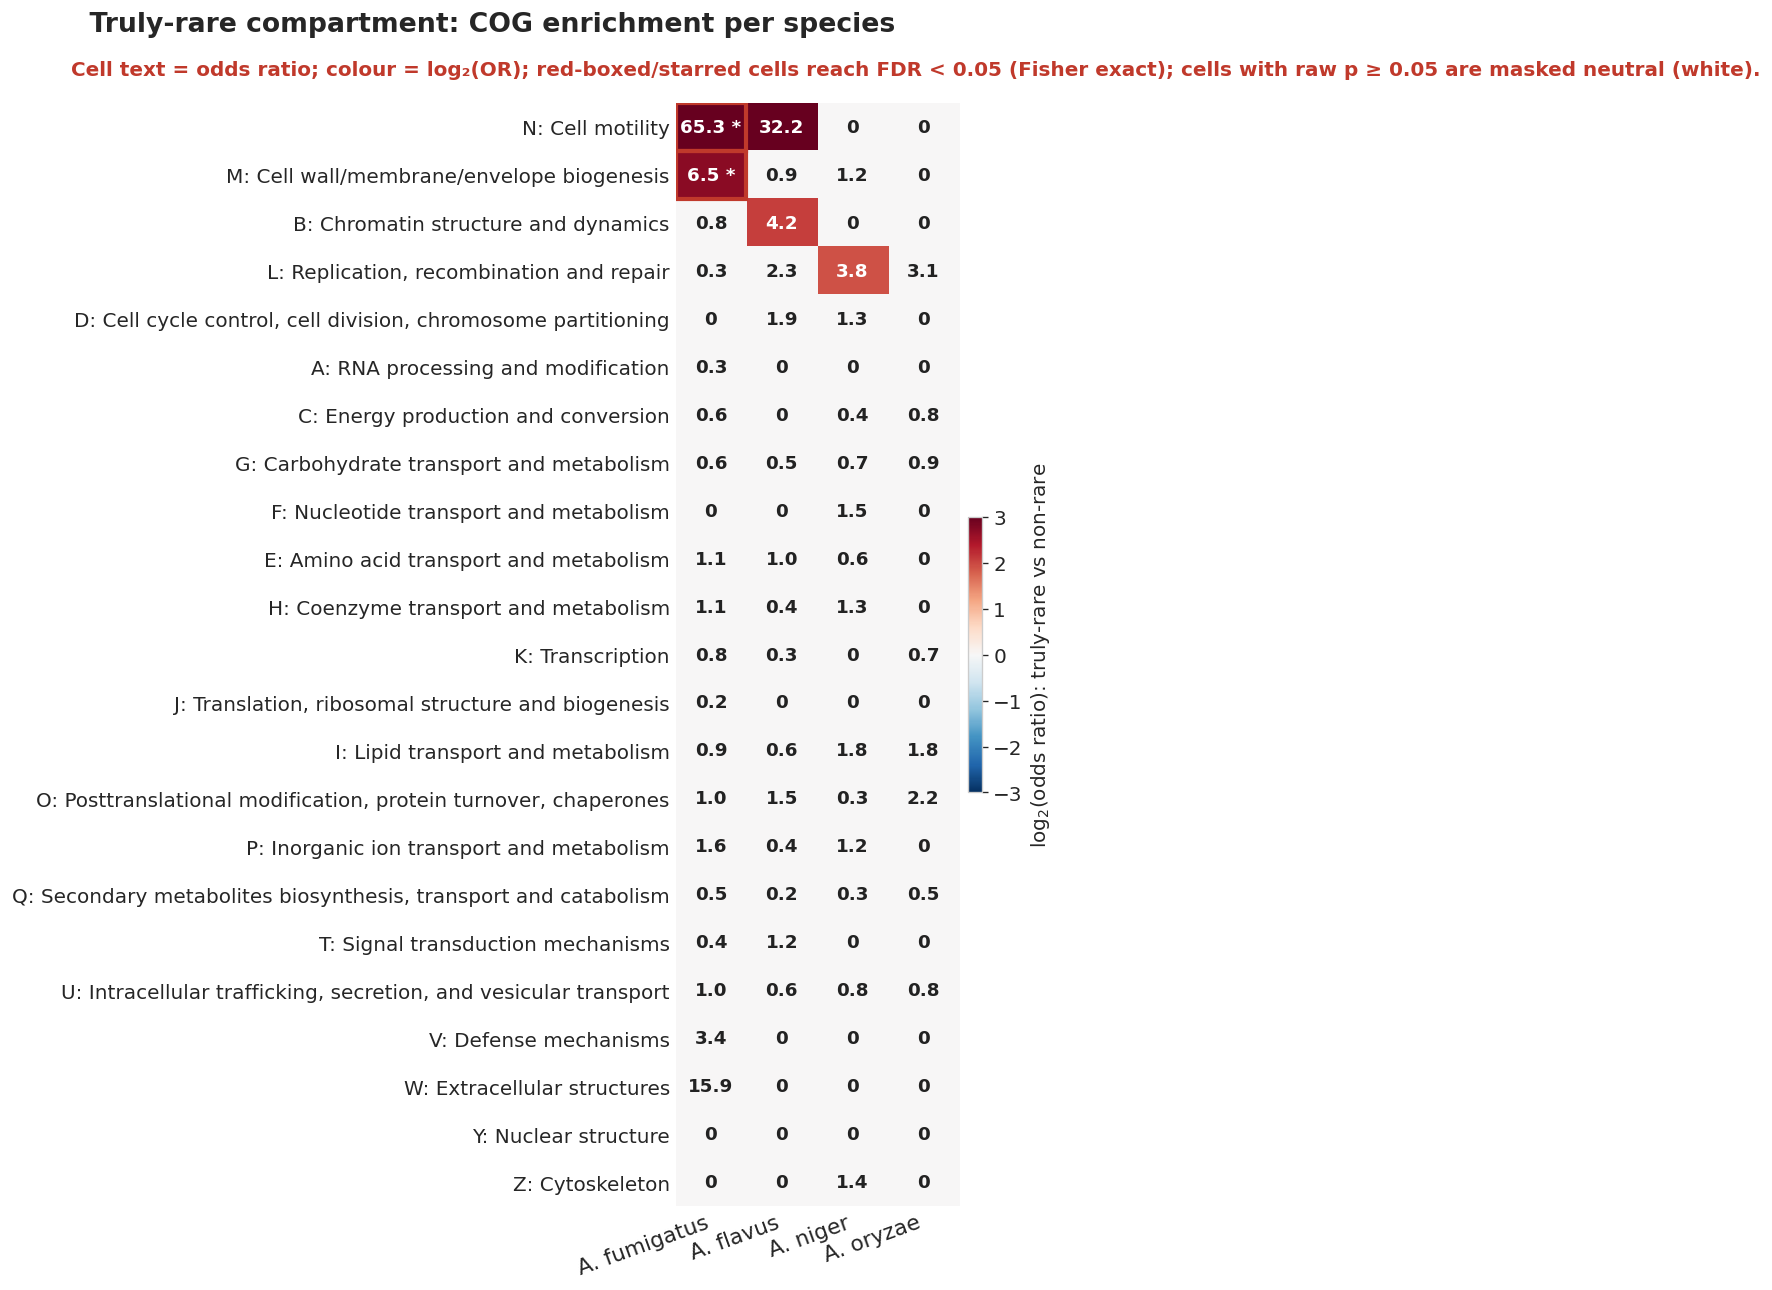

Saved -> /datadrive/Analysis/NB4_Results/rare_cog_characterisation.png  (+ .pdf)


In [34]:
# --- (c) Rare-OG characterisation: COG x species heatmap ---
# Heatmap of the truly-rare compartment: rows = COG categories,
# columns = species, cell shading = log2(odds ratio) of truly-rare
# vs non-rare enrichment (Fisher exact). Diverging palette centred at 0:
# red = enriched in truly-rare, blue = depleted. Cells reaching FDR < 0.05
# are outlined in red and starred. Cells whose OR=0 or OR=inf but do NOT
# reach raw p < 0.05 are masked to neutral (visually muted) so undersampled
# zero-cells do not visually overstate depletion.
# --- Tweakable parameters ---
FS_CG, DPI_CG = 14, 400
FIG_W_CG, FIG_H_CG = 9.0, 11.0
TOP_N_COG = None        # None = all COG categories; or an int for the top-N
LOR_CAP = 3.0           # cap log2(OR) at +/-3 for the colour scale
RAW_P_FOR_COLOR = 0.05  # OR=0 / OR=inf cells below this raw p stay coloured;
                        # above this they are masked to 0 (neutral white)

from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
NB4_RESULTS = Path('/datadrive/Analysis/NB4_Results')
SPECIES_ORDER = ['A. fumigatus', 'A. flavus', 'A. niger', 'A. oryzae']


_path = NB4_RESULTS / 'truly_rare_cog_enrichment.csv'
if not _path.exists():
    print(f'No COG enrichment table at {_path}.')
else:
    cog = pd.read_csv(_path)
    # COG label = "COG: description"
    cog['label'] = cog['COG'] + ': ' + cog['COG_description'].astype(str)

    # Compute log2(OR) from Odds_Ratio with safe handling of 0 and inf.
    # Mask non-significant zero/inf cells to neutral so they do not
    # dominate the figure (count-zero with small set is usually underpowered,
    # not real depletion).
    cog['Odds_Ratio_num'] = pd.to_numeric(cog['Odds_Ratio'], errors='coerce')
    cog['p_num']         = pd.to_numeric(cog['p_value'], errors='coerce').fillna(1.0)
    def _safe_log2_or(row):
        v, p = row['Odds_Ratio_num'], row['p_num']
        if pd.isna(v):              return 0.0
        # Mask ANY cell that does not reach raw p < RAW_P_FOR_COLOR.
        # This handles three cases together:
        #   (a) OR = 0 with small TR set (e.g. niger COG-K) - undersampled,
        #   (b) OR = inf with small non-rare set - undersampled,
        #   (c) finite-but-extreme OR from a single-gene call
        #       (e.g. fumigatus COG-W: 1 TR vs 5 non-rare, OR ~ 16, p = 0.073).
        # None of these deserve to dominate the figure visually.
        if p >= RAW_P_FOR_COLOR:    return 0.0
        if v == 0:                  return -LOR_CAP
        if np.isinf(v) or v > 1e3:  return  LOR_CAP
        return float(np.clip(np.log2(v), -LOR_CAP, LOR_CAP))
    cog['log2_OR'] = cog.apply(_safe_log2_or, axis=1)

    lor = cog.pivot_table(index='label', columns='Species',
                          values='log2_OR', aggfunc='sum',
                          fill_value=0).reindex(columns=SPECIES_ORDER, fill_value=0)
    OR  = cog.pivot_table(index='label', columns='Species',
                          values='Odds_Ratio_num', aggfunc='sum',
                          fill_value=np.nan).reindex(columns=SPECIES_ORDER, fill_value=np.nan)
    sig = cog.pivot_table(index='label', columns='Species',
                          values='Significant', aggfunc='max',
                          fill_value=False).reindex(columns=SPECIES_ORDER, fill_value=False)
    # Order rows by max |log2(OR)| across species (descending) so the
    # most enriched/depleted categories sit at the top.
    order = lor.abs().max(axis=1).sort_values(ascending=False).index
    lor = lor.loc[order]; OR = OR.loc[order]; sig = sig.loc[order]
    if TOP_N_COG:
        lor = lor.head(TOP_N_COG); OR = OR.loc[lor.index]; sig = sig.loc[lor.index]

    L = lor.values.astype(float)
    fig, ax = plt.subplots(figsize=(FIG_W_CG, FIG_H_CG))
    im = ax.imshow(L, aspect='auto', cmap='RdBu_r',
                   vmin=-LOR_CAP, vmax=LOR_CAP)
    ax.set_xticks(range(len(SPECIES_ORDER)))
    ax.set_xticklabels(SPECIES_ORDER, fontsize=FS_CG - 1, rotation=20, ha='right')
    ax.set_yticks(range(len(lor.index)))
    ax.set_yticklabels(lor.index, fontsize=FS_CG - 2)
    ax.grid(False)
    ax.tick_params(which='both', length=0)
    for s in ('top', 'right', 'left', 'bottom'):
        ax.spines[s].set_visible(False)

    # Cell text = OR (matches the colour scale).
    #   OR = 0           -> "0"
    #   OR = inf / >1e3  -> ">1e3"
    #   else             -> "{OR:.1f}"
    # Star FDR-significant cells; outline them in red.
    def _or_label(v):
        if pd.isna(v):                return ''
        if v == 0:                    return '0'
        if np.isinf(v) or v > 1e3:    return '>10³'
        return f'{v:.1f}'
    for i in range(L.shape[0]):
        for j in range(L.shape[1]):
            v = OR.values[i, j]
            star = ' *' if bool(sig.values[i, j]) else ''
            dark = abs(L[i, j]) > LOR_CAP * 0.55
            ax.text(j, i, f'{_or_label(v)}{star}', ha='center', va='center',
                    fontsize=FS_CG - 3, fontweight='bold',
                    color='white' if dark else '#222')
            if bool(sig.values[i, j]):     # red outline for FDR<0.05 cells
                ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                       edgecolor='#c0392b', linewidth=2.5))
    cb = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)
    cb.set_label(r'log$_2$(odds ratio): truly-rare vs non-rare',
                 fontsize=FS_CG - 2)
    cb.ax.tick_params(labelsize=FS_CG - 2)

    sigrows = cog[cog['Significant']]
    if len(sigrows):
        foot = ('Cell text = odds ratio; colour = log₂(OR); '
                'red-boxed/starred cells reach FDR < 0.05 (Fisher exact); '
                'cells with raw p ≥ 0.05 are masked neutral (white).')
    else:
        foot = 'No COG category reaches FDR < 0.05 in any species.'
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    fig.canvas.draw()
    _rend = fig.canvas.get_renderer()
    _left_px = min(lbl.get_window_extent(_rend).x0
                   for lbl in ax.get_yticklabels())
    _left = fig.transFigure.inverted().transform((_left_px, 0))[0]
    _left += 0.055
    _atop = ax.get_position().y1
    fig.text(_left, _atop + 0.050,
             '  Truly-rare compartment: COG enrichment per species',
             ha='left', va='bottom', fontsize=FS_CG + 2, fontweight='bold')
    fig.text(_left, _atop + 0.018, foot,
             ha='left', va='bottom', fontsize=FS_CG - 2, fontweight='bold',
             color='#c0392b')
    out = NB4_RESULTS / 'rare_cog_characterisation.png'
    fig.savefig(out, dpi=DPI_CG, bbox_inches='tight')
    fig.savefig(out.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}  (+ .pdf)')

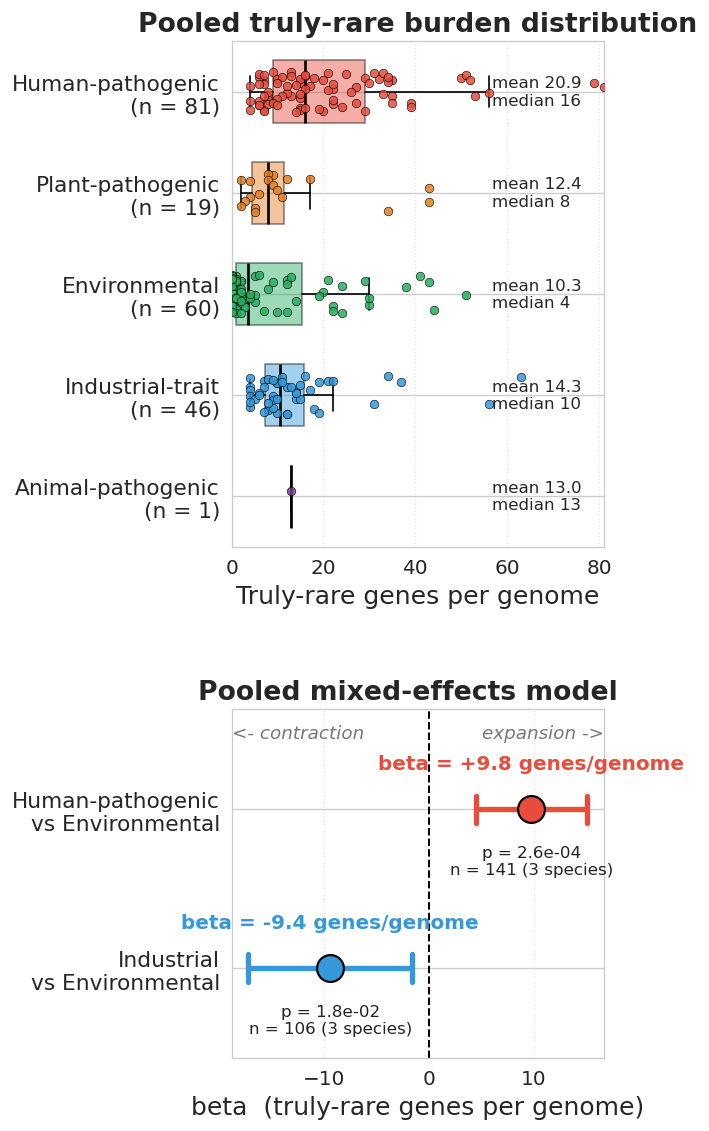

Saved -> /datadrive/Analysis/NB4_Results/truly_rare_burden_by_phenotype.png  (+ .pdf)


In [ ]:
# --- (d) Truly-rare gene burden by phenotype ---
# Stacked two-panel figure: (top) per-genome truly-rare burden distribution
# by phenotype; (bottom) forest plot of the pooled cross-species mixed-effects
# model TrulyRare_genes ~ phenotype + (1|Species) -- the single cross-species
# statistic per direction of the bidirectional model.
# --- Tweakable parameters ---
FS_TB, DPI_TB = 15, 400
FIG_W_TB, FIG_H_TB = 4.0, 11.0

from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt
NB4_RESULTS = Path('/datadrive/Analysis/NB4_Results')
# Phenotype palette = NB0 phenotype-distribution colours (UNIFIED_COLORS)
PHENO_COLORS = {'Human-pathogenic': '#e74c3c', 'Plant-pathogenic': '#e67e22',
                'Animal-pathogenic': '#7d3c98', 'Environmental': '#27ae60',
                'Industrial-trait': '#3498db'}
PHENO_ORDER = ['Human-pathogenic', 'Plant-pathogenic', 'Environmental',
               'Industrial-trait', 'Animal-pathogenic']

_path  = NB4_RESULTS / 'truly_rare_burden_all_genomes.csv'
mm_path = NB4_RESULTS / 'truly_rare_pooled_burden_mixed_model.csv'
if not _path.exists():
    print(f'No truly-rare burden table at {_path}.')
else:
    tb = pd.read_csv(_path)
    tb = tb[tb['Phenotype'].isin(PHENO_ORDER)]
    fig, (axT, axB) = plt.subplots(
        2, 1, figsize=(FIG_W_TB, FIG_H_TB),
        gridspec_kw=dict(height_ratios=[1.45, 1.0], hspace=0.38))

    # ---- TOP: per-genome burden distribution ----
    phs  = [p for p in PHENO_ORDER if p in tb['Phenotype'].unique()]
    xmax = tb['TrulyRare_genes'].max()
    for i, ph in enumerate(phs):
        vals = tb[tb['Phenotype'] == ph]['TrulyRare_genes'].values
        axT.boxplot([vals], positions=[i], widths=0.62, showfliers=False,
                    vert=False, patch_artist=True,
                    boxprops=dict(facecolor=PHENO_COLORS[ph], alpha=0.45,
                                  edgecolor='black'),
                    medianprops=dict(color='black', linewidth=1.6),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'))
        jit = np.random.RandomState(42).uniform(-0.20, 0.20, len(vals))
        axT.scatter(vals, [i] * len(vals) + jit, s=26, color=PHENO_COLORS[ph],
                    alpha=0.85, edgecolor='black', linewidth=0.4, zorder=3)
        axT.text(xmax * 0.7, i,
                 f'mean {vals.mean():.1f}\nmedian {np.median(vals):.0f}',
                 ha='left', va='center', fontsize=FS_TB - 5)
    axT.set_yticks(range(len(phs)))
    axT.set_yticklabels([f'{p}\n(n = {(tb["Phenotype"]==p).sum()})'
                         for p in phs], fontsize=FS_TB - 2)
    axT.set_xlabel('Truly-rare genes per genome', fontsize=FS_TB)
    axT.set_xlim(0, xmax * 1.0)
    axT.invert_yaxis()
    axT.tick_params(axis='x', labelsize=FS_TB - 3)
    axT.grid(True, axis='x', linestyle=':', alpha=0.5)
    axT.set_title('Pooled truly-rare burden distribution',
                  fontsize=FS_TB + 1, fontweight='bold')

    # ---- BOTTOM: pooled mixed-effects forest plot ----
    if mm_path.exists():
        mm   = pd.read_csv(mm_path)
        cmap = {'Human-pathogenic vs Environmental': '#e74c3c',
                'Industrial vs Environmental': '#3498db'}
        rows = list(mm.itertuples())
        ypos = [k * 1.5 for k in range(len(rows))]
        for y, r in zip(ypos, rows):
            col = cmap.get(r.contrast, '#555')
            axB.plot([r.CI_low_raw, r.CI_high_raw], [y, y], color=col,
                     linewidth=3.2, solid_capstyle='round', zorder=2)
            for xc in (r.CI_low_raw, r.CI_high_raw):
                axB.plot([xc, xc], [y - 0.13, y + 0.13], color=col,
                         linewidth=3.2, zorder=2)
            axB.scatter([r.beta_raw], [y], s=260, color=col,
                        edgecolor='black', linewidth=1.3, zorder=4)
            axB.text(r.beta_raw, y + 0.34, f'beta = {r.beta_raw:+.1f} genes/genome',
                     ha='center', va='bottom', fontsize=FS_TB - 3,
                     fontweight='bold', color=col)
            axB.text(r.beta_raw, y - 0.34,
                     #f'95% CI [{r.CI_low_raw:.1f}, {r.CI_high_raw:.1f}]    '
                     f'p = {r.p_raw:.1e}\nn = {r.n_total} '
                     f'({r.species_with_both_groups} species)',
                     ha='center', va='top', fontsize=FS_TB - 5, color='#222')
        axB.axvline(0, color='black', linestyle='--', linewidth=1.2)
        axB.set_yticks(ypos)
        axB.set_yticklabels([r.contrast.replace(' vs ', '\nvs ')
                             for r in rows], fontsize=FS_TB - 2)
        axB.set_ylim(min(ypos) - 0.85, max(ypos) + 0.95)
        axB.set_xlabel('beta  (truly-rare genes per genome)', fontsize=FS_TB)
        axB.tick_params(axis='x', labelsize=FS_TB - 3)
        xl = axB.get_xlim()
        ytop = max(ypos) + 0.72
        axB.text(xl[1], ytop, 'expansion ->', ha='right', va='center',
                 fontsize=FS_TB - 4, style='italic', color='#777')
        axB.text(xl[0], ytop, '<- contraction', ha='left', va='center',
                 fontsize=FS_TB - 4, style='italic', color='#777')
        axB.grid(True, axis='x', linestyle=':', alpha=0.5)
        axB.set_title('Pooled mixed-effects model  ',
                      #'TrulyRare ~ phenotype + (1|Species)',
                      fontsize=FS_TB + 1, fontweight='bold')
    else:
        axB.axis('off')
        axB.text(0.5, 0.5, 'No pooled mixed-model table.',
                 ha='center', va='center', fontsize=FS_TB)

    #fig.suptitle('Truly lineage-private (rare) gene burden by phenotype  '
    #             '(pooled across all four species)',
    #             fontsize=FS_TB + 2, fontweight='bold', y=0.99)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = NB4_RESULTS / 'truly_rare_burden_by_phenotype.png'
    fig.savefig(out, dpi=DPI_TB, bbox_inches='tight')
    fig.savefig(out.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}  (+ .pdf)')
